# PHẦN 0: CÀI ĐẶT THƯ VIỆN


In [44]:
pip install xgboost shap imbalanced-learn lightgbm tabulate statsmodels

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 11.7 MB/s eta 0:00:00a 0:00:01
Note: you may need to restart the kernel to use updated packages.


# PHẦN 1: THIẾT LẬP VÀ PHÂN CHIA DỮ LIỆU BAN ĐẦU


In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import random
import re
from sklearn.utils import resample
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from functools import partial
from sklearn.metrics import precision_recall_curve
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import ADASYN
from sklearn.svm import SVC
import lightgbm as lgb
import shap
import statsmodels.api as sm
from sklearn.datasets import make_circles
from sklearn import svm
from sklearn.calibration import calibration_curve, CalibrationDisplay
from sklearn.base import clone
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import brier_score_loss


In [46]:
SEED = 38
random.seed(SEED)
np.random.seed(SEED)
print(f"Đã cài đặt các thư viện và cố định Seed = {SEED}")

Đã cài đặt các thư viện và cố định Seed = 38


## 1.1. Tải dữ liệu

In [47]:
df = pd.read_excel('./dataset.xlsx')

## 1.2. Chuẩn hoá tên cột và xóa các biến không cần thiết

In [48]:
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(')', '')
delete_columns = ['ho_va_ten','gioi_tinh','dai_thao_duong','tang_huyet_ap','hoi_chung_vanh_man','ckd','copd','copd_mahoa','phan_loai_the_lam_sang','hcvc','van_mach','suy_ho_hap','rung_nhi','NT_proBNP_>_35000','NT_ProBNP','ket_cuc']
cols_to_drop_existing = [col for col in delete_columns if col in df.columns]
df.drop(columns=cols_to_drop_existing, inplace=True, errors='ignore')

## 1.3. Phân chia dữ liệu

In [49]:
X = df.drop('ketcuc_mahoa', axis=1)
y = df['ketcuc_mahoa']
X_dev, X_test, y_dev, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)
print(f"Kích thước Development Set: {X_dev.shape[0]} mẫu")
print(f"Kích thước Test Set: {X_test.shape[0]} mẫu")

Kích thước Development Set: 246 mẫu
Kích thước Test Set: 83 mẫu


# PHẦN 2: TIỀN XỬ LÝ SƠ BỘ

In [50]:
missing_data_columns_dev = X_dev.isnull().mean() * 100
threshold_column = 10
columns_to_drop = missing_data_columns_dev[missing_data_columns_dev > threshold_column].index
X_dev_cleaned = X_dev.drop(columns=columns_to_drop)
X_test_cleaned = X_test.drop(columns=columns_to_drop)

## Tách biến 'tong_GWTG' trước khi xử lý
y_scores_gwtg_train = X_dev_cleaned['tong_GWTG'].copy()
y_scores_gwtg_test = X_test_cleaned['tong_GWTG'].copy()
X_dev_cleaned = X_dev_cleaned.drop('tong_GWTG', axis=1)
X_test_cleaned = X_test_cleaned.drop('tong_GWTG', axis=1)
print("\nĐã tách 'tong_GWTG' ra khỏi tập dữ liệu chính.")

## Xuất file đã điền dữ liệu (imputed)
print("\nBắt đầu điền dữ liệu thiếu để xuất file...")
numeric_features = X_dev_cleaned.select_dtypes(include=np.number).columns.tolist()

# Tạo một preprocessor để điền dữ liệu
imputation_preprocessor = ColumnTransformer(
    transformers=[('num',
                   IterativeImputer(estimator=RandomForestRegressor(n_estimators=10, random_state=SEED), max_iter=10, random_state=SEED),
                   numeric_features)],
    remainder='passthrough'
)

# Fit và transform để có dữ liệu đã điền
imputation_preprocessor.fit(X_dev_cleaned)
X_dev_imputed_array = imputation_preprocessor.transform(X_dev_cleaned)
X_test_imputed_array = imputation_preprocessor.transform(X_test_cleaned)

# Chuyển lại thành DataFrame và ghép các cột cần thiết
df_dev_imputed = pd.DataFrame(X_dev_imputed_array, columns=X_dev_cleaned.columns, index=X_dev_cleaned.index)
df_dev_imputed['ketcuc_mahoa'] = y_dev
df_dev_imputed['tong_GWTG'] = y_scores_gwtg_train

df_test_imputed = pd.DataFrame(X_test_imputed_array, columns=X_test_cleaned.columns, index=X_test_cleaned.index)
df_test_imputed['ketcuc_mahoa'] = y_test
df_test_imputed['tong_GWTG'] = y_scores_gwtg_test

# Xuất file
dev_filename = 'development_set_imputed_unscaled.xlsx'
test_filename = 'test_set_imputed_unscaled.xlsx'
df_dev_imputed.to_excel(dev_filename, index=False)
df_test_imputed.to_excel(test_filename, index=False)


## Định nghĩa preprocessor (impute + scale) cho việc huấn luyện mô hình
num_pipe_full = Pipeline(steps=[
    ('imputer', IterativeImputer(estimator=RandomForestRegressor(n_estimators=10, random_state=SEED), max_iter=10, random_state=SEED)),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[('num', num_pipe_full, numeric_features)],
    remainder='passthrough'
)


Đã tách 'tong_GWTG' ra khỏi tập dữ liệu chính.

Bắt đầu điền dữ liệu thiếu để xuất file...


# PHẦN 3: XÂY DỰNG CÁC PIPELINE ĐÃ CẢI TIẾN

In [51]:
mi_classif_seeded = partial(mutual_info_classif, random_state=SEED)

# Sử dụng Class Weight
count_majority = y_dev.value_counts()[0]
count_minority = y_dev.value_counts()[1]
scale_pos_weight_value = count_majority / count_minority
class_weight_dict = {0: 1, 1: scale_pos_weight_value}
print(f"Trọng số tính được cho Class Weight (scale_pos_weight): {scale_pos_weight_value:.2f}\n")

# Thiết lập ADASYN
adasyn = ADASYN(random_state=SEED)
print("Đã thiết lập ADASYN để tích hợp vào pipeline.\n")

models = {
    "RF (ClassWeight)": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(mi_classif_seeded, k=15)),
        ('classifier', RandomForestClassifier(random_state=SEED, n_estimators=150, class_weight=class_weight_dict))
    ]),
    "LogReg (ClassWeight)": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(mi_classif_seeded, k=15)),
        ('classifier', LogisticRegression(random_state=SEED, max_iter=1000, class_weight=class_weight_dict))
    ]),
    "SVM (ClassWeight)": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(mi_classif_seeded, k=15)),
        ('classifier', SVC(probability=True, random_state=SEED, class_weight=class_weight_dict))
    ]),
    "XGBoost (ClassWeight)": Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(mi_classif_seeded, k=15)),
        ('classifier', XGBClassifier(random_state=SEED, eval_metric='logloss', scale_pos_weight=scale_pos_weight_value))
    ]),
    "RF (ADASYN)": ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(mi_classif_seeded, k=15)),
        ('adasyn', adasyn),
        ('classifier', RandomForestClassifier(random_state=SEED, n_estimators=150))
    ]),
    "LogReg (ADASYN)": ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(mi_classif_seeded, k=15)),
        ('adasyn', adasyn),
        ('classifier', LogisticRegression(random_state=SEED, max_iter=1000))
    ]),
    "SVM (ADASYN)": ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(mi_classif_seeded, k=15)),
        ('adasyn', adasyn),
        ('classifier', SVC(probability=True, random_state=SEED))
    ]),
    "XGBoost (ADASYN)": ImbPipeline(steps=[
        ('preprocessor', preprocessor),
        ('feature_selection', SelectKBest(mi_classif_seeded, k=15)),
        ('adasyn', adasyn),
        ('classifier', XGBClassifier(random_state=SEED, eval_metric='logloss'))
    ]),
}

Trọng số tính được cho Class Weight (scale_pos_weight): 11.30

Đã thiết lập ADASYN để tích hợp vào pipeline.



# PHẦN 3.5: PHÂN TÍCH ĐẶC TRƯNG ĐƯỢC CHỌN

In [52]:
temp_pipeline = models["RF (ClassWeight)"]
temp_pipeline.fit(X_dev_cleaned, y_dev)
selector_step = temp_pipeline.named_steps['feature_selection']
scores = selector_step.scores_
all_feature_names = X_dev_cleaned.columns
selected_features_mask = selector_step.get_support()
selected_feature_names = all_feature_names[selected_features_mask]

all_features_scores = pd.DataFrame({'Feature': all_feature_names, 'Mutual_Info_Score': scores})
selected_features_scores = all_features_scores[all_features_scores['Feature'].isin(selected_feature_names)]
selected_features_scores = selected_features_scores.sort_values(by='Mutual_Info_Score', ascending=False)
print("Đây là 15 đặc trưng được tất cả các mô hình sử dụng, cùng với điểm Mutual Information của chúng:")
print(selected_features_scores.to_string(index=False))

Đây là 15 đặc trưng được tất cả các mô hình sử dụng, cùng với điểm Mutual Information của chúng:
         Feature  Mutual_Info_Score
 choangtim_mahoa           0.069489
     matbu_mahoa           0.062759
  suyhohap_mahoa           0.052711
gioi_tinh_ma_hoa           0.047251
  ntprobnp_value           0.042752
      hcvc_mahoa           0.030799
   Troponin_I_hs           0.020163
            HATT           0.019970
             AST           0.019962
       dtd_mahoa           0.018147
             bmi           0.013538
           HATTr           0.011706
      Creatinine           0.009121
          adhere           0.006432
               K           0.005354


# PHẦN 4: HUẤN LUYỆN VÀ ĐÁNH GIÁ TẤT CẢ MÔ HÌNH


## 4.1. ĐÁNH GIÁ CHÉO 5-FOLD TRÊN TẬP DEVELOPMENT

In [53]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_results = {} # Khởi tạo dictionary để lưu kết quả

# Vòng lặp để thực hiện cross-validation và điền vào cv_results
for name, model in models.items():
    print(f"  - Đang đánh giá chéo mô hình: {name}...")
    # Dòng này thực hiện CV và trả về mảng các điểm AUC
    scores = cross_val_score(model, X_dev_cleaned, y_dev, cv=skf, scoring='roc_auc', n_jobs=-1)
    # Lưu kết quả vào dictionary
    cv_results[name] = scores

print("\nĐánh giá chéo hoàn tất!")

print("\n" + "-"*75)
print("BẢNG KẾT QUẢ ĐÁNH GIÁ CHÉO (AUC TRUNG BÌNH TRÊN TẬP DEV)")
print("-"*75)
print(f"{'Mô hình':<25} | {'AUC (Mean ± Std)':<30}")
print("-"*75)

cv_summary = {}
for name, scores in cv_results.items():
    mean_auc = np.mean(scores)
    std_auc = scores.std()
    median_auc = np.median(scores)
    cv_summary[name] = {'cv_median_auc': median_auc, 'cv_mean_auc': mean_auc, 'cv_std_auc': std_auc}
    print(f"{name:<25} | {mean_auc:.4f} ± {std_auc:.4f}")
print("-"*75)


  - Đang đánh giá chéo mô hình: RF (ClassWeight)...
  - Đang đánh giá chéo mô hình: LogReg (ClassWeight)...
  - Đang đánh giá chéo mô hình: SVM (ClassWeight)...
  - Đang đánh giá chéo mô hình: XGBoost (ClassWeight)...
  - Đang đánh giá chéo mô hình: RF (ADASYN)...
  - Đang đánh giá chéo mô hình: LogReg (ADASYN)...
  - Đang đánh giá chéo mô hình: SVM (ADASYN)...
  - Đang đánh giá chéo mô hình: XGBoost (ADASYN)...

Đánh giá chéo hoàn tất!

---------------------------------------------------------------------------
BẢNG KẾT QUẢ ĐÁNH GIÁ CHÉO (AUC TRUNG BÌNH TRÊN TẬP DEV)
---------------------------------------------------------------------------
Mô hình                   | AUC (Mean ± Std)              
---------------------------------------------------------------------------
RF (ClassWeight)          | 0.7640 ± 0.1634
LogReg (ClassWeight)      | 0.7459 ± 0.0902
SVM (ClassWeight)         | 0.7655 ± 0.1522
XGBoost (ClassWeight)     | 0.7928 ± 0.1121
RF (ADASYN)               | 0.8102 ± 0

/var/folders/3s/zltsvmc54fq7vrpdxp8mypz00000gr/T/ipykernel_33734/2292336697.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_cw = sns.boxplot(data=df_plot_cw, x='Model', y='ROC AUC Score',


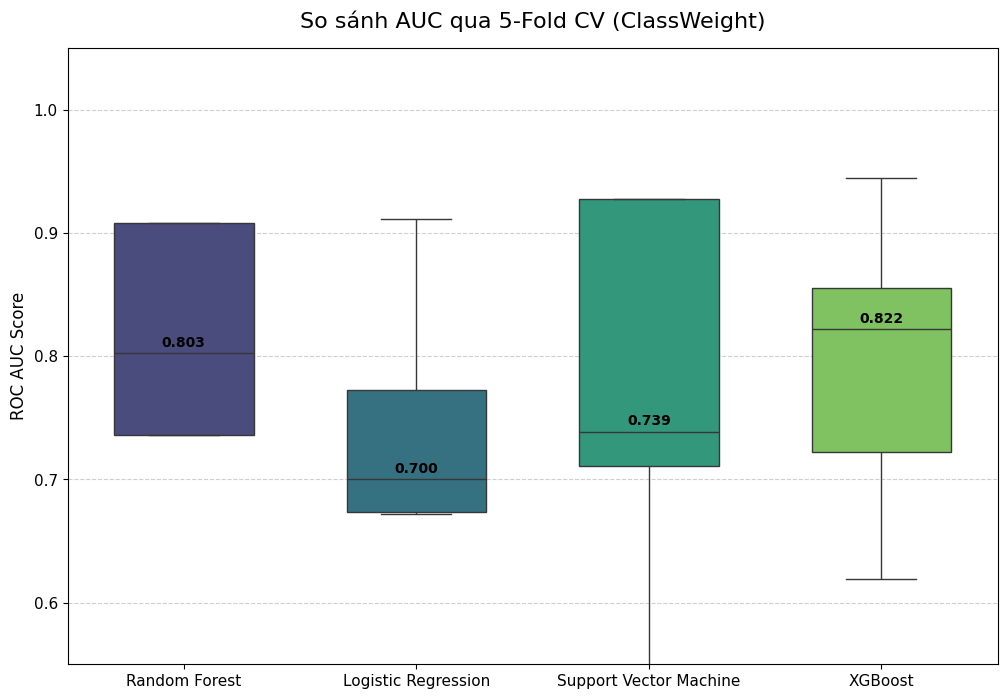

In [54]:
plot_data_cw = []
model_mapping_cw = {
    'RF (ClassWeight)': 'Random Forest',
    'LogReg (ClassWeight)': 'Logistic Regression',
    'SVM (ClassWeight)': 'Support Vector Machine',
    'XGBoost (ClassWeight)': 'XGBoost'
    }
model_order_cw = list(model_mapping_cw.values())

for original_name, simple_name in model_mapping_cw.items():
    if original_name in cv_results:
        for score in cv_results[original_name]:
            plot_data_cw.append({'Model': simple_name, 'ROC AUC Score': score})
df_plot_cw = pd.DataFrame(plot_data_cw)

plt.figure(figsize=(12, 8))
ax_cw = sns.boxplot(data=df_plot_cw, x='Model', y='ROC AUC Score',
                    order=model_order_cw, palette='viridis', width=0.6)
plt.title('So sánh AUC qua 5-Fold CV (ClassWeight)', fontsize=16, pad=15)
plt.ylabel('ROC AUC Score', fontsize=12); plt.xlabel('')
plt.xticks(fontsize=11); plt.yticks(fontsize=11)
plt.ylim(0.55, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.6)

medians_cw = df_plot_cw.groupby(['Model'])['ROC AUC Score'].median()
for i, model_name in enumerate(model_order_cw):
    median_val = medians_cw[model_name]
    ax_cw.text(i, median_val + 0.005, f'{median_val:.3f}',
             horizontalalignment='center', size='medium', color='black', weight='semibold')
plt.show()

/var/folders/3s/zltsvmc54fq7vrpdxp8mypz00000gr/T/ipykernel_33734/3731997171.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax_adasyn = sns.boxplot(data=df_plot_adasyn, x='Model', y='ROC AUC Score',


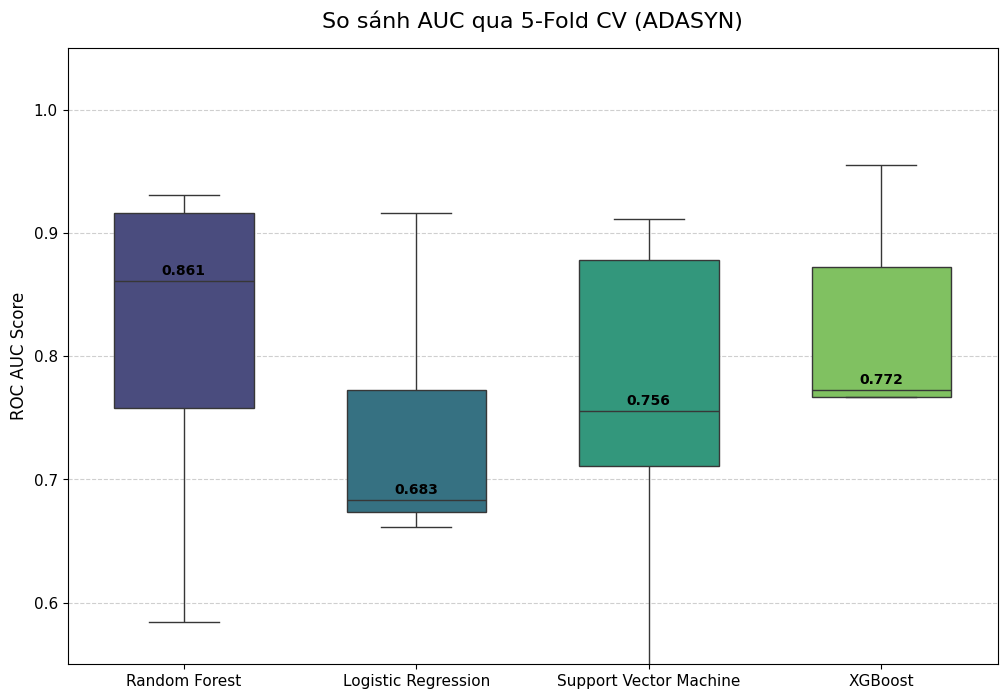

In [55]:
plot_data_adasyn = []
model_mapping_adasyn = {
    'RF (ADASYN)': 'Random Forest',
    'LogReg (ADASYN)': 'Logistic Regression',
    'SVM (ADASYN)': 'Support Vector Machine',
    'XGBoost (ADASYN)': 'XGBoost'
    }
model_order_adasyn = list(model_mapping_adasyn.values())

for original_name, simple_name in model_mapping_adasyn.items():
    if original_name in cv_results:
        for score in cv_results[original_name]:
            plot_data_adasyn.append({'Model': simple_name, 'ROC AUC Score': score})
df_plot_adasyn = pd.DataFrame(plot_data_adasyn)

plt.figure(figsize=(12, 8))
ax_adasyn = sns.boxplot(data=df_plot_adasyn, x='Model', y='ROC AUC Score',
                        order=model_order_adasyn, palette='viridis', width=0.6)
plt.title('So sánh AUC qua 5-Fold CV (ADASYN)', fontsize=16, pad=15)
plt.ylabel('ROC AUC Score', fontsize=12); plt.xlabel('')
plt.xticks(fontsize=11); plt.yticks(fontsize=11)
plt.ylim(0.55, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Thêm giá trị trung vị
medians_adasyn = df_plot_adasyn.groupby(['Model'])['ROC AUC Score'].median()
for i, model_name in enumerate(model_order_adasyn):
    median_val = medians_adasyn[model_name]
    ax_adasyn.text(i, median_val + 0.005, f'{median_val:.3f}',
                 horizontalalignment='center', size='medium', color='black', weight='semibold')
plt.show()

## 4.2. HUẤN LUYỆN LẠI TẤT CẢ MÔ HÌNH TRÊN TOÀN BỘ TẬP DEV

In [56]:
final_results = {}
for name, model in models.items():
    print(f"  - Đang huấn luyện mô hình: {name}...")
    model.fit(X_dev_cleaned, y_dev)
    auc_train = roc_auc_score(y_dev, model.predict_proba(X_dev_cleaned)[:, 1])
    auc_test = roc_auc_score(y_test, model.predict_proba(X_test_cleaned)[:, 1])
    final_results[name] = {
        'model': model,
        'cv_median_auc': cv_summary[name]['cv_median_auc'],
        'cv_std_auc': cv_summary[name]['cv_std_auc'],
        'auc_train': auc_train,
        'auc_test': auc_test
    }
print("\nHuấn luyện hoàn tất!")

  - Đang huấn luyện mô hình: RF (ClassWeight)...
  - Đang huấn luyện mô hình: LogReg (ClassWeight)...
  - Đang huấn luyện mô hình: SVM (ClassWeight)...
  - Đang huấn luyện mô hình: XGBoost (ClassWeight)...
  - Đang huấn luyện mô hình: RF (ADASYN)...
  - Đang huấn luyện mô hình: LogReg (ADASYN)...
  - Đang huấn luyện mô hình: SVM (ADASYN)...
  - Đang huấn luyện mô hình: XGBoost (ADASYN)...

Huấn luyện hoàn tất!


## 4.3. BẢNG TỔNG KẾT HIỆU SUẤT

In [57]:
auc_gwtg_train = roc_auc_score(y_dev, y_scores_gwtg_train)
auc_gwtg_test = roc_auc_score(y_test, y_scores_gwtg_test)
final_results['GWTG Score'] = {
    'model': None,
    'cv_median_auc': np.nan,
    'cv_std_auc': np.nan,
    'auc_train': auc_gwtg_train,
    'auc_test': auc_gwtg_test
}

results_df = pd.DataFrame.from_dict(final_results, orient='index')
results_df['overfitting_diff'] = results_df['auc_train'] - results_df['auc_test']
results_df = results_df.sort_values(by='cv_median_auc', ascending=False)  # Sắp xếp theo cv_median_auc

display_columns = ['cv_median_auc', 'cv_std_auc', 'auc_train', 'auc_test', 'overfitting_diff']
print("\nBẢNG TỔNG HỢP HIỆU SUẤT MÔ HÌNH")
print(results_df[display_columns].to_markdown(floatfmt=".4f"))


BẢNG TỔNG HỢP HIỆU SUẤT MÔ HÌNH
|                       |   cv_median_auc |   cv_std_auc |   auc_train |   auc_test |   overfitting_diff |
|:----------------------|----------------:|-------------:|------------:|-----------:|-------------------:|
| RF (ADASYN)           |          0.8611 |       0.1282 |      1.0000 |     0.8656 |             0.1344 |
| XGBoost (ClassWeight) |          0.8222 |       0.1121 |      1.0000 |     0.8553 |             0.1447 |
| RF (ClassWeight)      |          0.8028 |       0.1634 |      1.0000 |     0.8449 |             0.1551 |
| XGBoost (ADASYN)      |          0.7722 |       0.1593 |      1.0000 |     0.7932 |             0.2068 |
| SVM (ADASYN)          |          0.7556 |       0.1329 |      0.9985 |     0.6974 |             0.3011 |
| SVM (ClassWeight)     |          0.7389 |       0.1522 |      1.0000 |     0.7274 |             0.2726 |
| LogReg (ClassWeight)  |          0.7000 |       0.0902 |      0.9338 |     0.8120 |             0.1218 |
| Lo

# PHẦN 5: VẼ BIỂU ĐỒ SO SÁNH CUỐI CÙNG TRÊN TẬP TEST


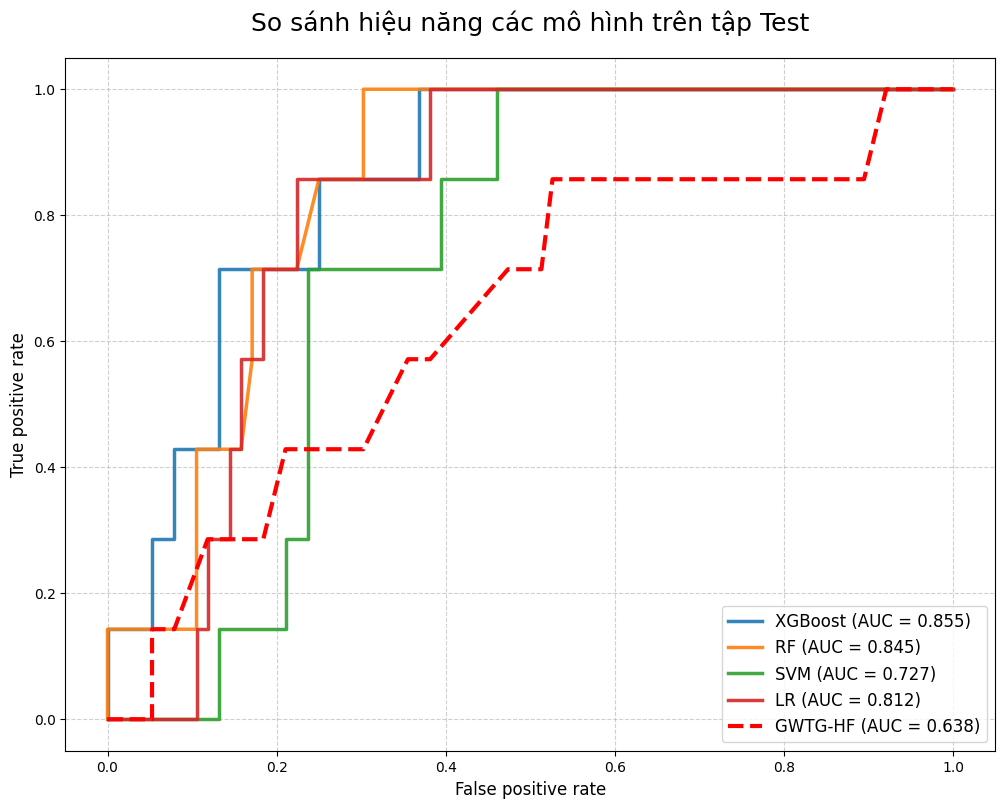

In [58]:
class_weight_models = [name for name in results_df.index if "ClassWeight" in name]
adasyn_models = [name for name in results_df.index if "ADASYN" in name]

plt.figure(figsize=(12, 9))
plt.title('So sánh hiệu năng các mô hình trên tập Test', fontsize=18, pad=20)

def display_name(raw_name: str) -> str:
    """Chuẩn hoá tên hiển thị gọn."""
    s = raw_name.lower()
    if "log" in s and "reg" in s:
        return "LR"
    if "rf" in s or "random forest" in s:
        return "RF"
    if "xgboost" in s or "xgb" in s:
        return "XGBoost"
    if "svm" in s:
        return "SVM"
    if "gwtg" in s:
        return "GWTG-HF"
    # fallback: bỏ phần (ClassWeight) hoặc (ADASYN)
    import re
    return re.sub(r"\s*\(.*?\)", "", raw_name).strip()

# Vẽ các mô hình ML
for name in class_weight_models:
    if "LightGBM" in name:
        continue

    result = final_results[name]
    y_pred_proba_ml = result['model'].predict_proba(X_test_cleaned)[:, 1]
    fpr_ml, tpr_ml, _ = roc_curve(y_test, y_pred_proba_ml)
    auc_score_ml = result['auc_test']

    label_ml = f"{display_name(name)} (AUC = {auc_score_ml:.3f})"
    plt.plot(fpr_ml, tpr_ml, label=label_ml, linewidth=2.5, alpha=0.9)

# Vẽ đường GWTG-HF và đường tham chiếu
fpr_gwtg, tpr_gwtg, _ = roc_curve(y_test, y_scores_gwtg_test)
label_gwtg = f"GWTG-HF (AUC = {final_results['GWTG Score']['auc_test']:.3f})"
plt.plot(fpr_gwtg, tpr_gwtg, label=label_gwtg, linewidth=3, linestyle='--', color='red')

plt.xlabel('False positive rate', fontsize=12)
plt.ylabel('True positive rate', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


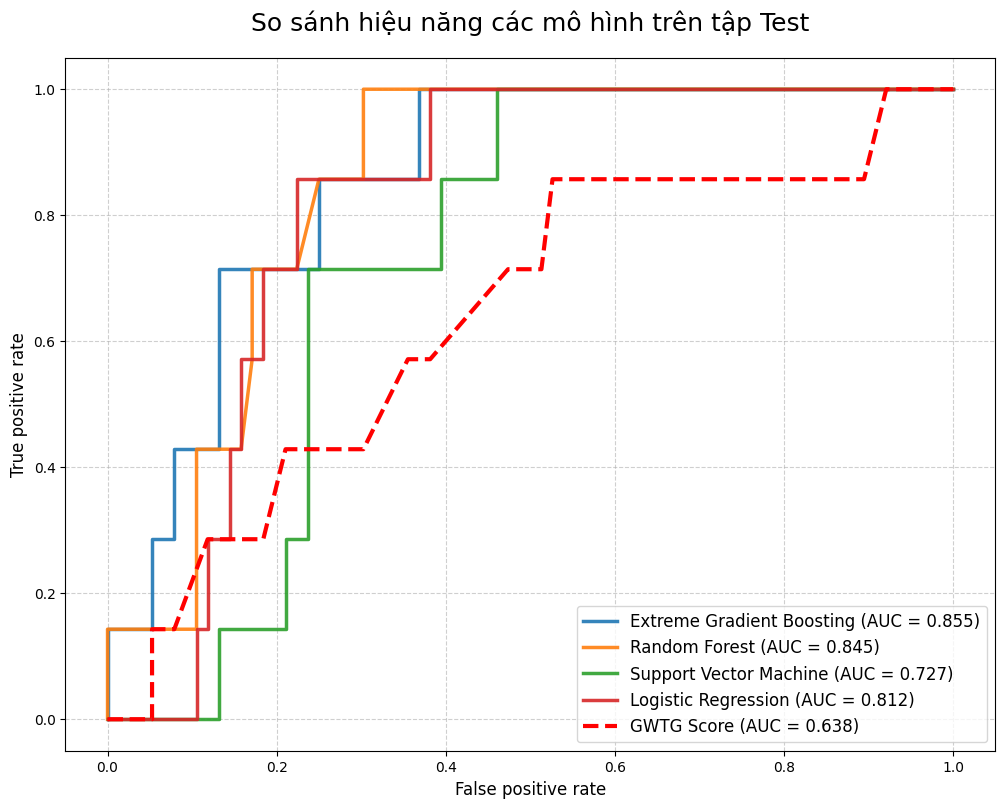

In [59]:
model_name_mapping = {
    "RF": "Random Forest",
    "XGBoost": "Extreme Gradient Boosting",
    "SVM": "Support Vector Machine",
    "LogReg": "Logistic Regression",
    "GWTG Score": "GWTG Score"
}

class_weight_models = [name for name in results_df.index if "ClassWeight" in name]
adasyn_models = [name for name in results_df.index if "ADASYN" in name]

plt.figure(figsize=(12, 9))
plt.title('So sánh hiệu năng các mô hình trên tập Test', fontsize=18, pad=20)

for name in class_weight_models:
    if "LightGBM" in name:
        continue

    result = final_results[name]
    y_pred_proba_ml = result['model'].predict_proba(X_test_cleaned)[:, 1]
    fpr_ml, tpr_ml, _ = roc_curve(y_test, y_pred_proba_ml)
    auc_score_ml = result['auc_test']

    # Đổi sang tên đầy đủ
    simple_name = name.replace(" (ClassWeight)", "")
    display_name = model_name_mapping.get(simple_name, simple_name)  # fallback nếu không có trong dict
    label_ml = f"{display_name} (AUC = {auc_score_ml:.3f})"

    plt.plot(fpr_ml, tpr_ml, label=label_ml, linewidth=2.5, alpha=0.9)

# Vẽ đường GWTG
fpr_gwtg, tpr_gwtg, _ = roc_curve(y_test, y_scores_gwtg_test)
label_gwtg = f"{model_name_mapping['GWTG Score']} (AUC = {final_results['GWTG Score']['auc_test']:.3f})"
plt.plot(fpr_gwtg, tpr_gwtg, label=label_gwtg, linewidth=3, linestyle='--', color='red')

plt.xlabel('False positive rate', fontsize=12)
plt.ylabel('True positive rate', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

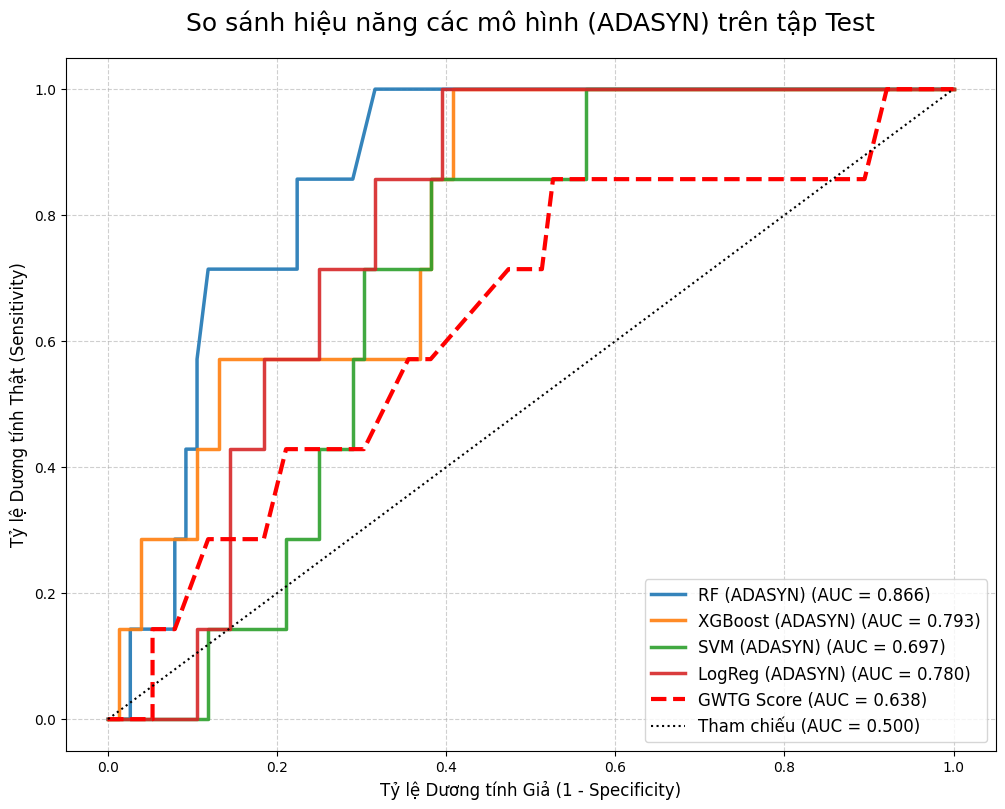

In [60]:
plt.figure(figsize=(12, 9))
plt.title('So sánh hiệu năng các mô hình (ADASYN) trên tập Test', fontsize=18, pad=20)
for name in adasyn_models:
    result = final_results[name]
    y_pred_proba_ml = result['model'].predict_proba(X_test_cleaned)[:, 1]
    fpr_ml, tpr_ml, _ = roc_curve(y_test, y_pred_proba_ml)
    auc_score_ml = result['auc_test']
    label_ml = f"{name} (AUC = {auc_score_ml:.3f})"
    plt.plot(fpr_ml, tpr_ml, label=label_ml, linewidth=2.5, alpha=0.9)

fpr_gwtg, tpr_gwtg, _ = roc_curve(y_test, y_scores_gwtg_test)
label_gwtg = f"GWTG Score (AUC = {final_results['GWTG Score']['auc_test']:.3f})"
plt.plot(fpr_gwtg, tpr_gwtg, label=label_gwtg, linewidth=3, linestyle='--', color='red')
plt.plot([0, 1], [0, 1], 'k:', label='Tham chiếu (AUC = 0.500)')
plt.xlabel('Tỷ lệ Dương tính Giả (1 - Specificity)', fontsize=12)
plt.ylabel('Tỷ lệ Dương tính Thật (Sensitivity)', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# PHẦN 5.5: PHÂN TÍCH HIỆU CHUẨN (CALIBRATION) CỦA CÁC MÔ HÌNH

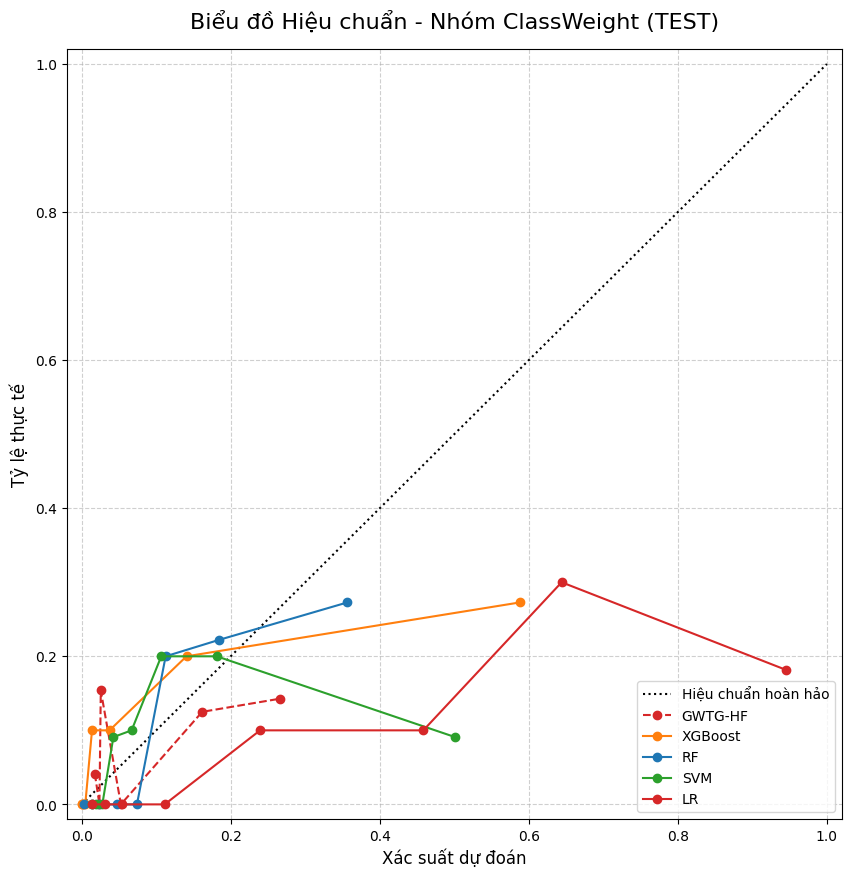

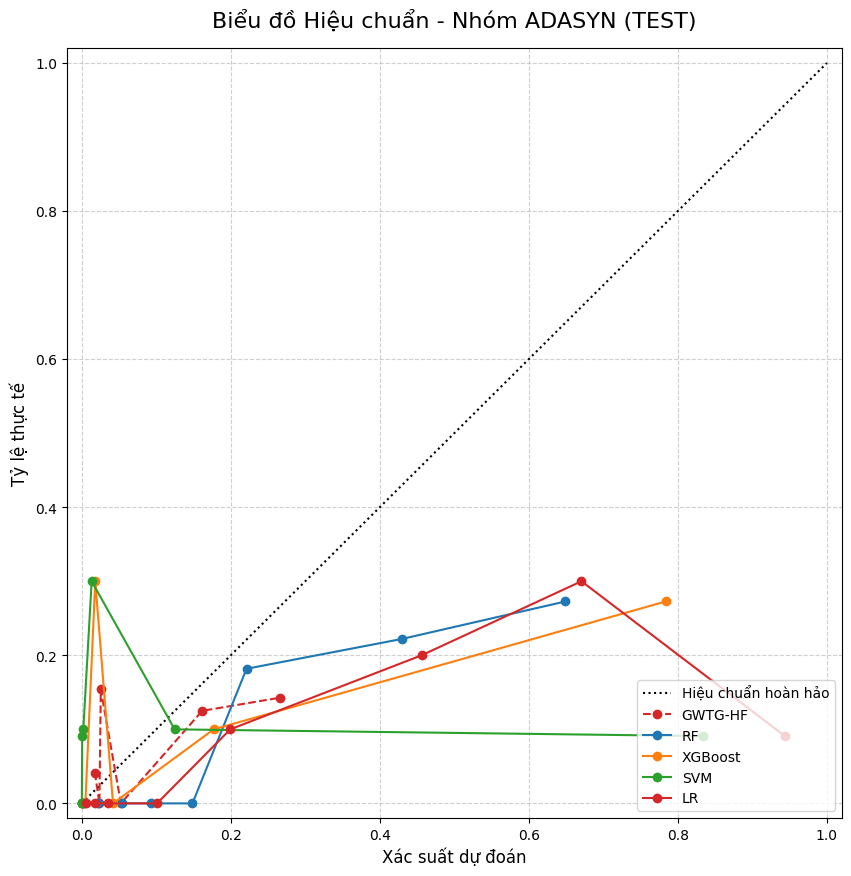

GWTG-HF - Brier: 0.0825 | Intercept: -1.516 | Slope: 0.308
⚠️  Có bin của GWTG-HF với <2 biến cố. Cân nhắc giảm N_BINS hoặc gộp bin ở vùng đuôi.


In [61]:
N_BINS = 8
BIN_STRATEGY = "quantile"

# --- chuẩn hóa vector ---
y_dev_arr   = np.asarray(y_dev).ravel()
y_test_arr  = np.asarray(y_test).ravel()
gwtg_dev    = np.asarray(y_scores_gwtg_train).ravel()   # điểm GWTG trên DEV
gwtg_test   = np.asarray(y_scores_gwtg_test).ravel()    # điểm GWTG trên TEST

# kiểm tra độ dài
assert len(gwtg_dev)  == len(y_dev_arr),  f"DEV length mismatch: {len(gwtg_dev)} vs {len(y_dev_arr)}"
assert len(gwtg_test) == len(y_test_arr), f"TEST length mismatch: {len(gwtg_test)} vs {len(y_test_arr)}"

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(gwtg_dev, y_dev_arr)
y_prob_gwtg_test = iso.transform(gwtg_test)

STYLE = {
    "GWTG-HF": dict(color="C3", linestyle="--"),
    "RF":      dict(color="C0", linestyle="-"),
    "XGBoost": dict(color="C1", linestyle="-"),
    "SVM":     dict(color="C2", linestyle="-"),
    "LR":      dict(color="C3", linestyle="-"),
}

calibration_data_list = []  # reset mỗi lần chạy cell

def add_curve(ax, name, y_true, y_prob, group):
    """Vẽ calibration theo quantile-bins và lưu n/events từng bin."""
    pt, pp = calibration_curve(y_true, y_prob, n_bins=N_BINS, strategy=BIN_STRATEGY)
    style = STYLE.get(name, {})
    ax.plot(pp, pt, marker="o",
            linestyle=style.get("linestyle", "-"),
            color=style.get("color", None),
            label=name)

    # đếm n/events theo cùng cách chia bin (quantile trên y_prob)
    q = np.quantile(y_prob, np.linspace(0, 1, N_BINS + 1))
    bin_idx = np.digitize(y_prob, q[1:-1], right=False)
    y_true_arr = np.asarray(y_true).ravel()

    for i, (pp_i, pt_i) in enumerate(zip(pp, pt)):
        m = (bin_idx == i)
        calibration_data_list.append({
            "Mô hình": name, "Nhóm": group, "Bin": i + 1,
            "n": int(m.sum()), "Số biến cố": int(y_true_arr[m].sum()),
            "Tỷ lệ thực tế (y)": float(pt_i),
            "Xác suất dự đoán trung bình (x)": float(pp_i),
        })

def base_axes(title):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.plot([0, 1], [0, 1], "k:", label="Hiệu chuẩn hoàn hảo")
    ax.set_xlabel("Xác suất dự đoán", fontsize=12)
    ax.set_ylabel("Tỷ lệ thực tế", fontsize=12)
    ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])
    ax.set_title(title, fontsize=16, pad=15)
    ax.grid(True, linestyle="--", alpha=0.6)
    return fig, ax

# ánh xạ tên hiển thị chuẩn
def display_name(raw_name: str) -> str:
    s = raw_name.lower()
    if "gwtg" in s: return "GWTG-HF"
    if "random" in s and "forest" in s: return "RF"
    if "xgboost" in s or "xgb" in s:     return "XGBoost"
    if "svm" in s or "support" in s:     return "SVM"
    if "logistic" in s or "logreg" in s or ("log" in s and "reg" in s) or "logit" in s: return "LR"
    import re
    return re.sub(r"\s*\(.*?\)", "", raw_name).strip()

fig_cw, ax_cw = base_axes("Biểu đồ Hiệu chuẩn - Nhóm ClassWeight (TEST)")
add_curve(ax_cw, "GWTG-HF", y_test_arr, y_prob_gwtg_test, "So sánh")

for name in class_weight_models:
    mdl = final_results[name]["model"]
    y_prob = mdl.predict_proba(X_test_cleaned)[:, 1]
    add_curve(ax_cw, display_name(name), y_test_arr, y_prob, "ClassWeight")

ax_cw.legend(loc="lower right"); plt.show()

fig_ada, ax_ada = base_axes("Biểu đồ Hiệu chuẩn - Nhóm ADASYN (TEST)")
add_curve(ax_ada, "GWTG-HF", y_test_arr, y_prob_gwtg_test, "So sánh")

for name in adasyn_models:
    mdl = final_results[name]["model"]
    y_prob = mdl.predict_proba(X_test_cleaned)[:, 1]
    add_curve(ax_ada, display_name(name), y_test_arr, y_prob, "ADASYN")

ax_ada.legend(loc="lower right"); plt.show()

calibration_df = pd.DataFrame(calibration_data_list)

try:
    import statsmodels.api as sm, statsmodels.formula.api as smf
    eps = 1e-12
    p = np.clip(y_prob_gwtg_test, eps, 1 - eps)
    df_cal = pd.DataFrame({"y": y_test_arr, "lp": np.log(p / (1 - p))})
    fit = smf.glm("y ~ lp", data=df_cal, family=sm.families.Binomial()).fit()
    brier = brier_score_loss(y_test_arr, p)
    intercept = float(fit.params["Intercept"])
    slope = float(fit.params["lp"])
    print("GWTG-HF - Brier: {:.4f} | Intercept: {:.3f} | Slope: {:.3f}"
          .format(brier, intercept, slope))

    gmask = calibration_df["Mô hình"] == "GWTG-HF"
    if gmask.any() and int(calibration_df.loc[gmask, "Số biến cố"].min()) < 2:
        print("⚠️  Có bin của GWTG-HF với <2 biến cố. Cân nhắc giảm N_BINS hoặc gộp bin ở vùng đuôi.")
except Exception as e:
    print("Bỏ qua tính Brier/intercept/slope (cần statsmodels): {}".format(e))



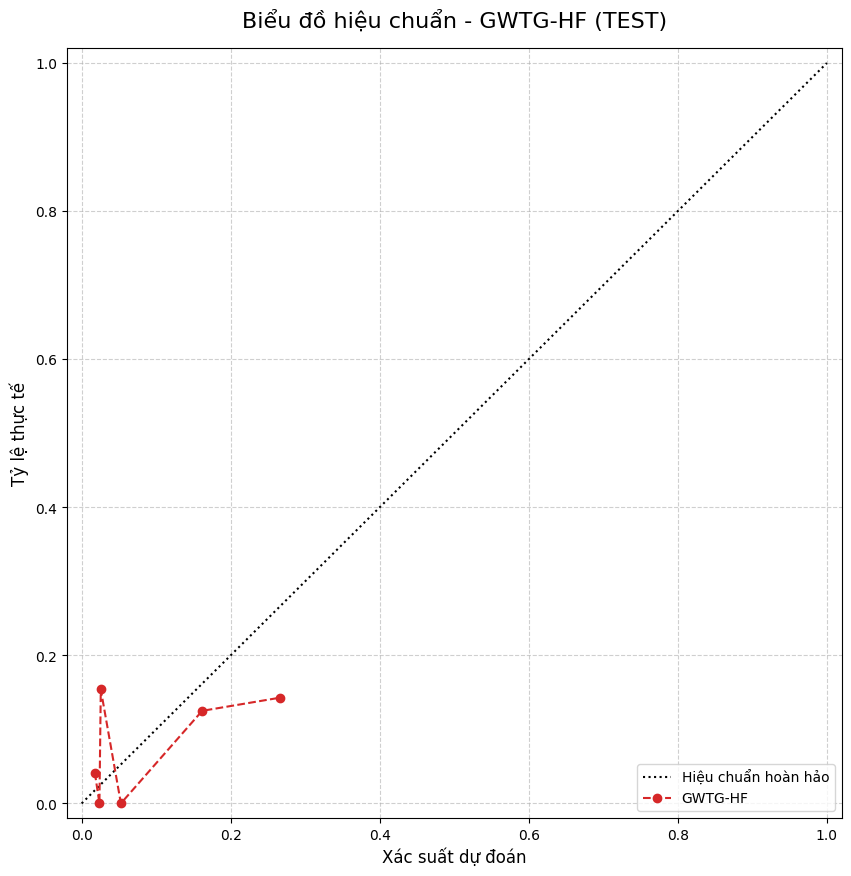

GWTG-HF - Brier: 0.0825 | Intercept: -1.516 | Slope: 0.308
⚠️  Có bin của GWTG-HF với <2 biến cố. Cân nhắc giảm N_BINS hoặc gộp bin ở vùng đuôi.


In [62]:
N_BINS = 8
BIN_STRATEGY = "quantile"
y_dev_arr   = np.asarray(y_dev).ravel()
y_test_arr  = np.asarray(y_test).ravel()
gwtg_dev    = np.asarray(y_scores_gwtg_train).ravel()   # điểm GWTG trên DEV
gwtg_test   = np.asarray(y_scores_gwtg_test).ravel()    # điểm GWTG trên TEST

assert len(gwtg_dev)  == len(y_dev_arr),  f"DEV length mismatch: {len(gwtg_dev)} vs {len(y_dev_arr)}"
assert len(gwtg_test) == len(y_test_arr), f"TEST length mismatch: {len(gwtg_test)} vs {len(y_test_arr)}"

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(gwtg_dev, y_dev_arr)
y_prob_gwtg_test = iso.transform(gwtg_test)

STYLE = {"GWTG-HF": dict(color="C3", linestyle="--")}

calibration_data_list = []

def add_curve(ax, name, y_true, y_prob, group):
    pt, pp = calibration_curve(y_true, y_prob, n_bins=N_BINS, strategy=BIN_STRATEGY)
    style = STYLE.get(name, {})
    ax.plot(pp, pt, marker="o",
            linestyle=style.get("linestyle", "-"),
            color=style.get("color", None),
            label=name)

    # gom thống kê từng bin
    q = np.quantile(y_prob, np.linspace(0, 1, N_BINS + 1))
    bin_idx = np.digitize(y_prob, q[1:-1], right=False)
    y_true_arr = np.asarray(y_true).ravel()
    for i, (pp_i, pt_i) in enumerate(zip(pp, pt)):
        m = (bin_idx == i)
        calibration_data_list.append({
            "Mô hình": name, "Nhóm": group, "Bin": i + 1,
            "n": int(m.sum()), "Số biến cố": int(y_true_arr[m].sum()),
            "Tỷ lệ thực tế (y)": float(pt_i),
            "Xác suất dự đoán trung bình (x)": float(pp_i),
        })

def base_axes(title):
    fig, ax = plt.subplots(figsize=(10, 10))
    ax.plot([0, 1], [0, 1], "k:", label="Hiệu chuẩn hoàn hảo")
    ax.set_xlabel("Xác suất dự đoán", fontsize=12)
    ax.set_ylabel("Tỷ lệ thực tế", fontsize=12)
    ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])
    ax.set_title(title, fontsize=16, pad=15)
    ax.grid(True, linestyle="--", alpha=0.6)
    return fig, ax

fig, ax = base_axes("Biểu đồ hiệu chuẩn - GWTG-HF (TEST)")
add_curve(ax, "GWTG-HF", y_test_arr, y_prob_gwtg_test, "GWTG-HF")
ax.legend(loc="lower right"); plt.show()

calibration_df = pd.DataFrame(calibration_data_list)

try:
    import statsmodels.api as sm, statsmodels.formula.api as smf
    eps = 1e-12
    p = np.clip(y_prob_gwtg_test, eps, 1 - eps)
    df_cal = pd.DataFrame({"y": y_test_arr, "lp": np.log(p / (1 - p))})
    fit = smf.glm("y ~ lp", data=df_cal, family=sm.families.Binomial()).fit()
    brier = brier_score_loss(y_test_arr, p)
    intercept = float(fit.params["Intercept"])
    slope = float(fit.params["lp"])
    print("GWTG-HF - Brier: {:.4f} | Intercept: {:.3f} | Slope: {:.3f}"
          .format(brier, intercept, slope))

    gmask = calibration_df["Mô hình"] == "GWTG-HF"
    if gmask.any() and int(calibration_df.loc[gmask, "Số biến cố"].min()) < 2:
        print("⚠️  Có bin của GWTG-HF với <2 biến cố. Cân nhắc giảm N_BINS hoặc gộp bin ở vùng đuôi.")
except Exception as e:
    print("Bỏ qua tính Brier/intercept/slope (cần statsmodels): {}".format(e))



In [63]:

def ex(n): return n in globals()
print("Có sẵn:", [n for n in [
    'y_dev','y_train','y_test',
    'y_scores_gwtg_train','y_scores_gwtg_test',
    'X_dev_cleaned','X_train_cleaned','X_test_cleaned',
    'df','y'
] if ex(n)])

if ex('y_scores_gwtg_train'):
    print('len(y_scores_gwtg_train)=', len(np.asarray(y_scores_gwtg_train).ravel()))
if ex('y_scores_gwtg_test'):
    print('len(y_scores_gwtg_test)=', len(np.asarray(y_scores_gwtg_test).ravel()))

def df_info(name):
    d = globals()[name]
    print(f'[{name}] shape={d.shape}')
    cols = list(map(str, d.columns))
    print('  first 20 cols:', cols[:20])
    pats = ['ketcuc','ket_cuc','label','outcome','death','tuvong','mortality']
    cand = [c for c in cols if any(re.search(p, c, flags=re.I) for p in pats)]
    # giữ cột numeric có thể là nhãn nhị phân
    cbin = []
    for c in cand:
        s = d[c]
        if pd.api.types.is_numeric_dtype(s) and s.dropna().isin([0,1]).mean() >= 0.9:
            cbin.append(c)
    print('  candidate label columns (binary-like):', cbin)

for name in ['X_dev_cleaned','X_train_cleaned','X_test_cleaned','df']:
    if ex(name) and isinstance(globals()[name], pd.DataFrame):
        df_info(name)

if ex('y') and isinstance(y, (pd.Series, pd.DataFrame)):
    if isinstance(y, pd.Series):
        print('y series: len=', len(y), '| unique=', list(pd.Series(y).unique())[:10])
    else:
        print('y dataframe columns:', list(y.columns)[:10])


Có sẵn: ['y_dev', 'y_test', 'y_scores_gwtg_train', 'y_scores_gwtg_test', 'X_dev_cleaned', 'X_test_cleaned', 'df', 'y']
len(y_scores_gwtg_train)= 246
len(y_scores_gwtg_test)= 83
[X_dev_cleaned] shape=(246, 35)
  first 20 cols: ['tuoi', 'gioi_tinh_ma_hoa', 'bmi', 'dtd_mahoa', 'tha_mahoa', 'hcvm_mahoa', 'ckd_mahoa', 'matbu_mahoa', 'oab_mahoa', 'choangtim_mahoa', 'mach', 'HATT', 'HATTr', 'hcvc_mahoa', 'suyhohap_mahoa', 'rungnhi_mahoa', 'QTc', 'QRS', 'WBC', 'Hb']
  candidate label columns (binary-like): []
[X_test_cleaned] shape=(83, 35)
  first 20 cols: ['tuoi', 'gioi_tinh_ma_hoa', 'bmi', 'dtd_mahoa', 'tha_mahoa', 'hcvm_mahoa', 'ckd_mahoa', 'matbu_mahoa', 'oab_mahoa', 'choangtim_mahoa', 'mach', 'HATT', 'HATTr', 'hcvc_mahoa', 'suyhohap_mahoa', 'rungnhi_mahoa', 'QTc', 'QRS', 'WBC', 'Hb']
  candidate label columns (binary-like): []
[df] shape=(329, 39)
  first 20 cols: ['tuoi', 'gioi_tinh_ma_hoa', 'bmi', 'dtd_mahoa', 'tha_mahoa', 'hcvm_mahoa', 'ckd_mahoa', 'matbu_mahoa', 'oab_mahoa', 'choangt

In [64]:
N_BINS = 8
BIN_STRATEGY = "quantile"

models_for_cal = [
    'RF (ClassWeight)',
    'LogReg (ClassWeight)',
    'SVM (ClassWeight)',
    'XGBoost (ClassWeight)'
]

y_dev_arr  = np.asarray(y_dev).ravel()
y_test_arr = np.asarray(y_test).ravel()
gwtg_dev   = np.asarray(y_scores_gwtg_train).ravel()
gwtg_test  = np.asarray(y_scores_gwtg_test).ravel()

iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(gwtg_dev, y_dev_arr)
y_prob_gwtg_test = iso.transform(gwtg_test)

def calibration_metrics(y_true, y_prob):
    eps = 1e-12
    p = np.clip(y_prob, eps, 1-eps)
    df = pd.DataFrame({"y": y_true, "lp": np.log(p/(1-p))})
    model = sm.GLM(df["y"], sm.add_constant(df["lp"]), family=sm.families.Binomial())
    fit = model.fit()
    intercept = float(fit.params["const"])
    slope = float(fit.params["lp"])
    brier = brier_score_loss(y_true, p)
    return brier, intercept, slope

def bootstrap_ci(y_true, y_prob, n_boot=1000, seed=42):
    rng = np.random.default_rng(seed)
    b_list, a_list, s_list = [], [], []
    for _ in range(n_boot):
        idx = rng.choice(len(y_true), size=len(y_true), replace=True)
        try:
            b,a,s = calibration_metrics(y_true[idx], y_prob[idx])
            b_list.append(b); a_list.append(a); s_list.append(s)
        except: pass
    def ci95(v): return np.percentile(v, [2.5, 97.5])
    b0,a0,s0 = calibration_metrics(y_true, y_prob)
    return {
        "Brier": b0, "Brier_CI95": ci95(b_list),
        "Intercept": a0, "Intercept_CI95": ci95(a_list),
        "Slope": s0, "Slope_CI95": ci95(s_list)
    }

results = {}

results["GWTG (Isotonic)"] = bootstrap_ci(y_test_arr, y_prob_gwtg_test)

for name in models_for_cal:
    mdl = final_results[name]["model"]
    prob_dev  = mdl.predict_proba(X_dev_cleaned)[:,1]
    prob_test = mdl.predict_proba(X_test_cleaned)[:,1]
    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(prob_dev, y_dev_arr)
    prob_test_cal = iso.transform(prob_test)
    results[f"{name} (Isotonic)"] = bootstrap_ci(y_test_arr, prob_test_cal)

summary = []
for k,v in results.items():
    summary.append({
        "Mô hình": k,
        "Brier": f"{v['Brier']:.3f} ({v['Brier_CI95'][0]:.3f} – {v['Brier_CI95'][1]:.3f})",
        "Intercept": f"{v['Intercept']:.3f} ({v['Intercept_CI95'][0]:.3f} – {v['Intercept_CI95'][1]:.3f})",
        "Slope": f"{v['Slope']:.3f} ({v['Slope_CI95'][0]:.3f} – {v['Slope_CI95'][1]:.3f})",
    })

calibration_summary = pd.DataFrame(summary)
display(calibration_summary)


/Users/top/miniconda3/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/Users/top/miniconda3/lib/python3.12/site-packages/statsmodels/genmod/families/links.py:198: RuntimeWarning: overflow encountered in exp
  t = np.exp(-z)
/Users/top/miniconda3/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/top/miniconda3/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detected, parameter may not be identified
  warnings.warn(msg, category=PerfectSeparationWarning)
/Users/top/miniconda3/lib/python3.12/site-packages/statsmodels/genmod/generalized_linear_model.py:1342: PerfectSeparationWarning: Perfect separation or prediction detecte

,Mô hình,Brier,Intercept,Slope
0,GWTG (Isotonic),0.083 (0.037 – 0.134),-1.516 (-3.200 – 0.588),0.308 (-0.028 – 1.179)
1,RF (ClassWeight) (Isotonic),0.079 (0.032 – 0.136),-1.043 (-23.292 – 0.105),0.064 (-0.737 – 0.146)
2,LogReg (ClassWeight) (Isotonic),0.127 (0.072 – 0.185),-1.679 (-2.859 – -0.690),0.081 (0.048 – 0.239)
3,SVM (ClassWeight) (Isotonic),0.131 (0.062 – 0.201),-22.309 (-23.483 – -18.473),-0.724 (-0.772 – -0.580)
4,XGBoost (ClassWeight) (Isotonic),0.092 (0.043 – 0.151),-0.763 (-2.520 – 0.265),0.097 (0.028 – 0.288)


# PHẦN 6: PHÂN TÍCH SÂU CÁC MÔ HÌNH


## 6.1. PHÂN TÍCH ĐỘ QUAN TRỌNG CỦA ĐẶC TRƯNG CHO TỪNG MÔ HÌNH



------------------------------ RF (CLASSWEIGHT) ------------------------------
Top 10 đặc trưng quan trọng nhất:
        Feature  Importance
  Troponin_I_hs    0.123755
choangtim_mahoa    0.117390
         adhere    0.093584
            AST    0.093087
 ntprobnp_value    0.092307
    matbu_mahoa    0.090456
     Creatinine    0.072997
           HATT    0.068349
            bmi    0.066832
              K    0.053413


/var/folders/3s/zltsvmc54fq7vrpdxp8mypz00000gr/T/ipykernel_33734/1479282165.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


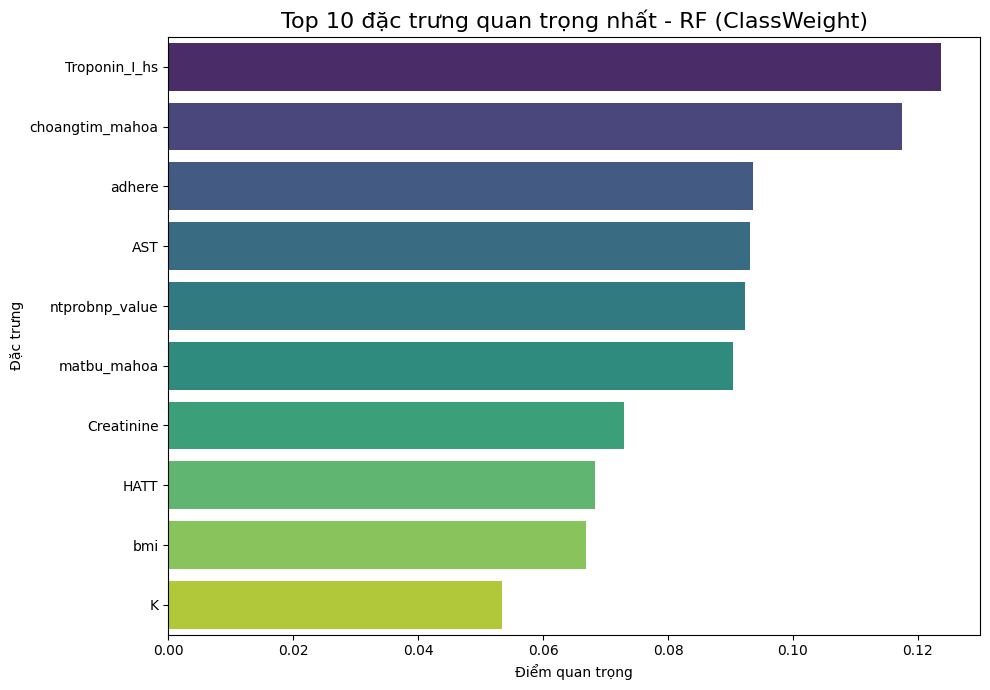

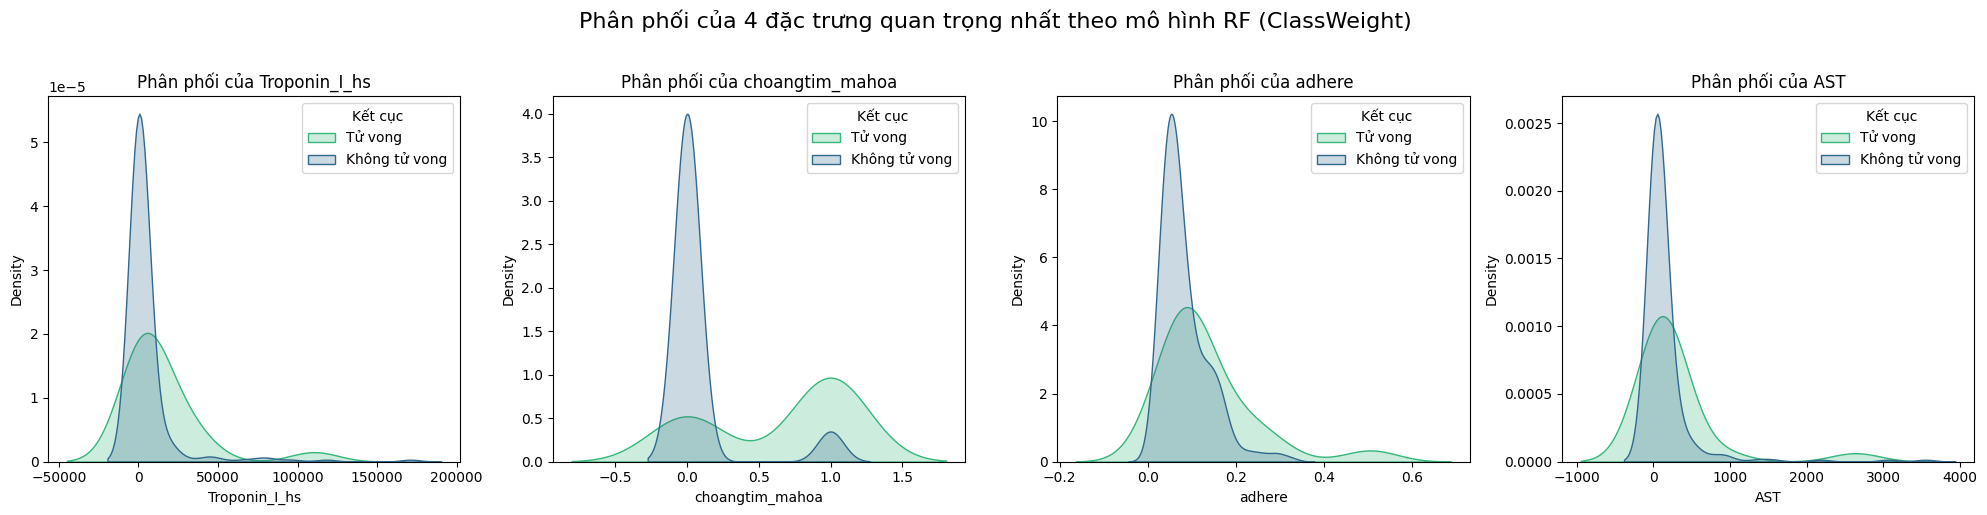


------------------------------ LOGREG (CLASSWEIGHT) ------------------------------
Top 10 đặc trưng quan trọng nhất:
         Feature  Importance
  ntprobnp_value    1.228354
 choangtim_mahoa    1.110907
gioi_tinh_ma_hoa    0.576946
      hcvc_mahoa    0.506485
          adhere    0.462224
       dtd_mahoa    0.439556
           HATTr    0.403611
            HATT    0.395359
  suyhohap_mahoa    0.389890
             bmi    0.367628


/var/folders/3s/zltsvmc54fq7vrpdxp8mypz00000gr/T/ipykernel_33734/1479282165.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


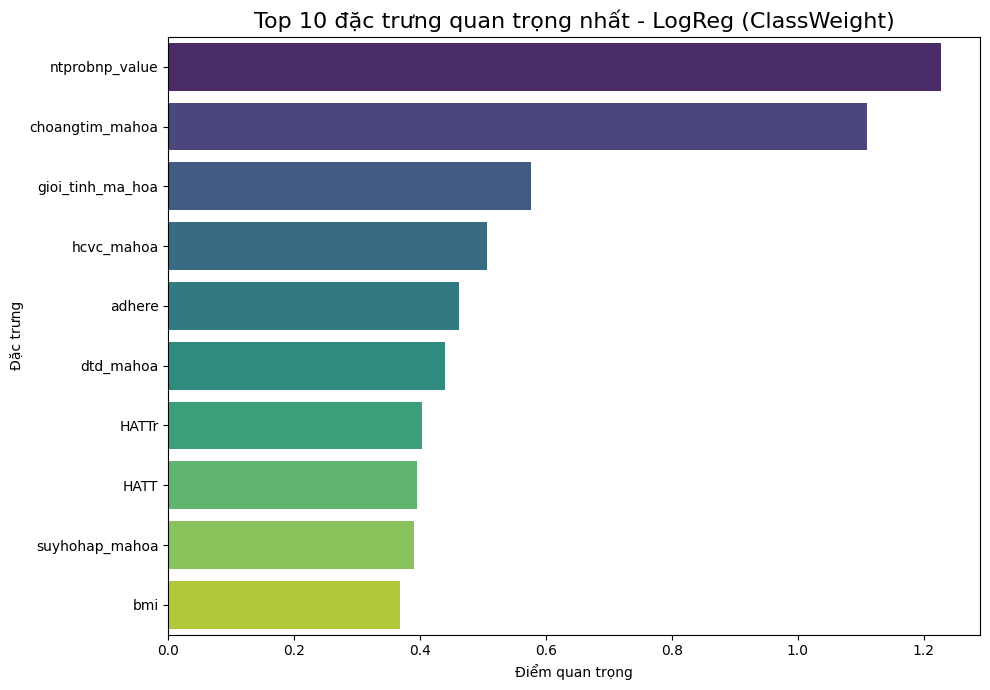

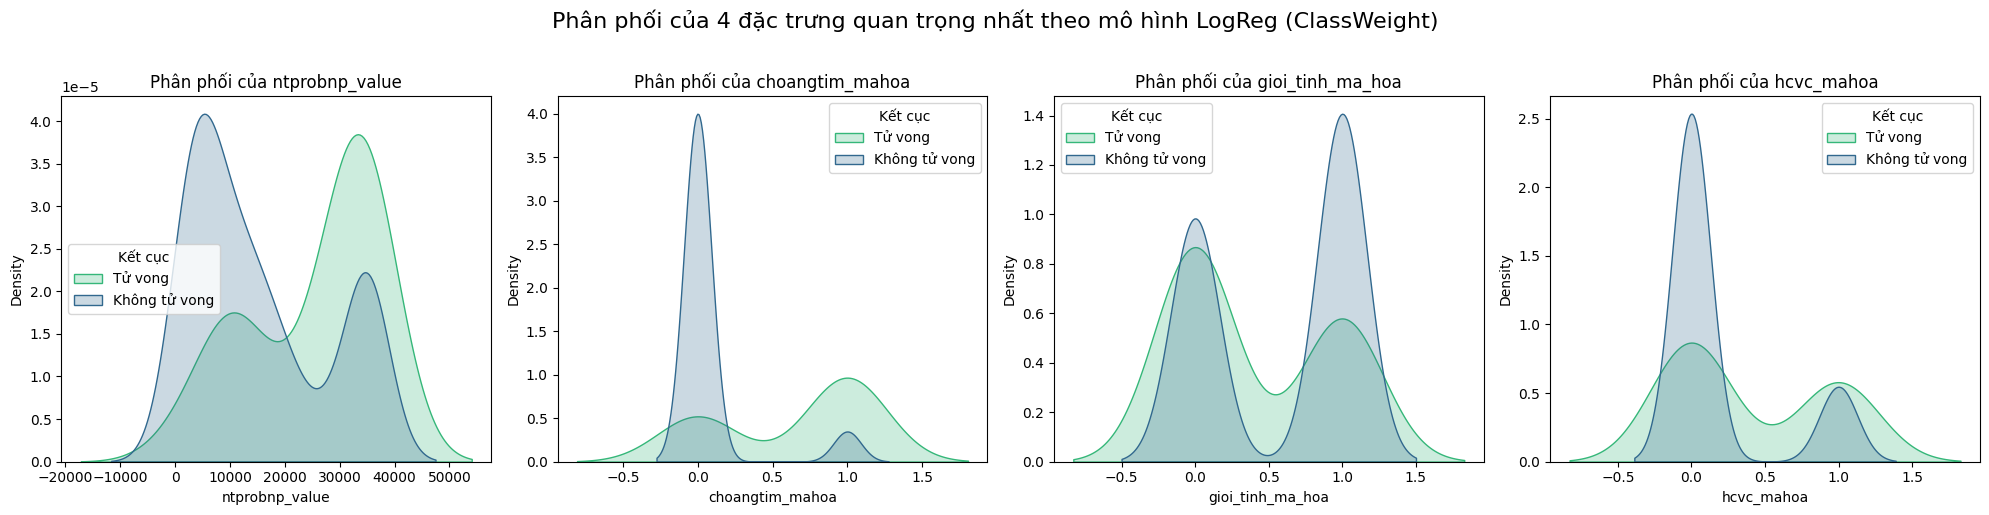


------------------------------ SVM (CLASSWEIGHT) ------------------------------
Top 10 đặc trưng quan trọng nhất:
         Feature  Importance
  ntprobnp_value    1.228354
 choangtim_mahoa    1.110907
gioi_tinh_ma_hoa    0.576946
      hcvc_mahoa    0.506485
          adhere    0.462224
       dtd_mahoa    0.439556
           HATTr    0.403611
            HATT    0.395359
  suyhohap_mahoa    0.389890
             bmi    0.367628


/var/folders/3s/zltsvmc54fq7vrpdxp8mypz00000gr/T/ipykernel_33734/1479282165.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


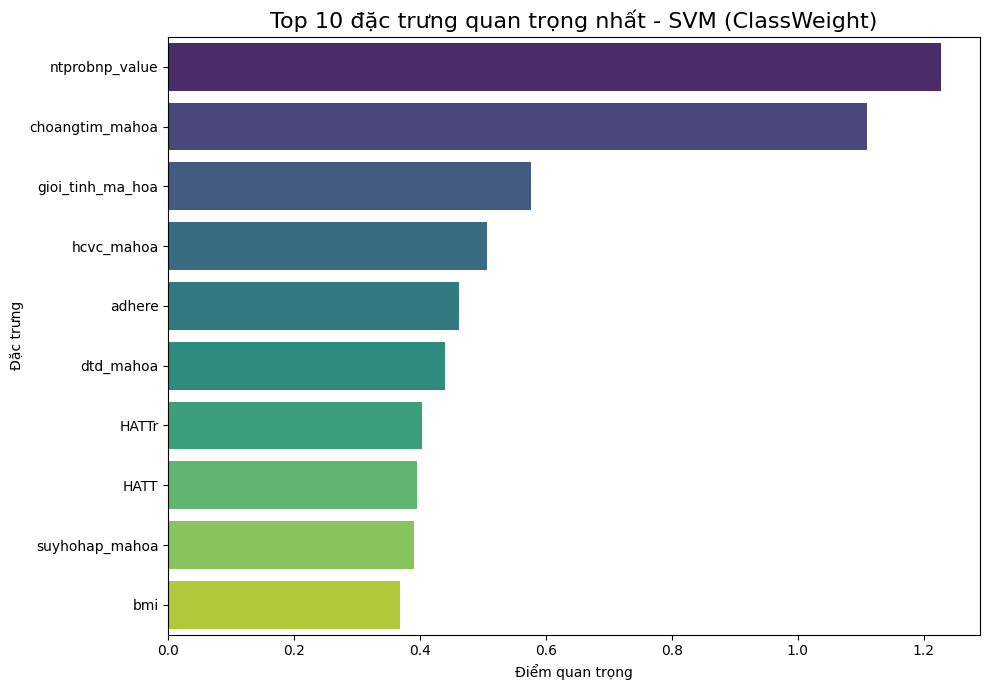

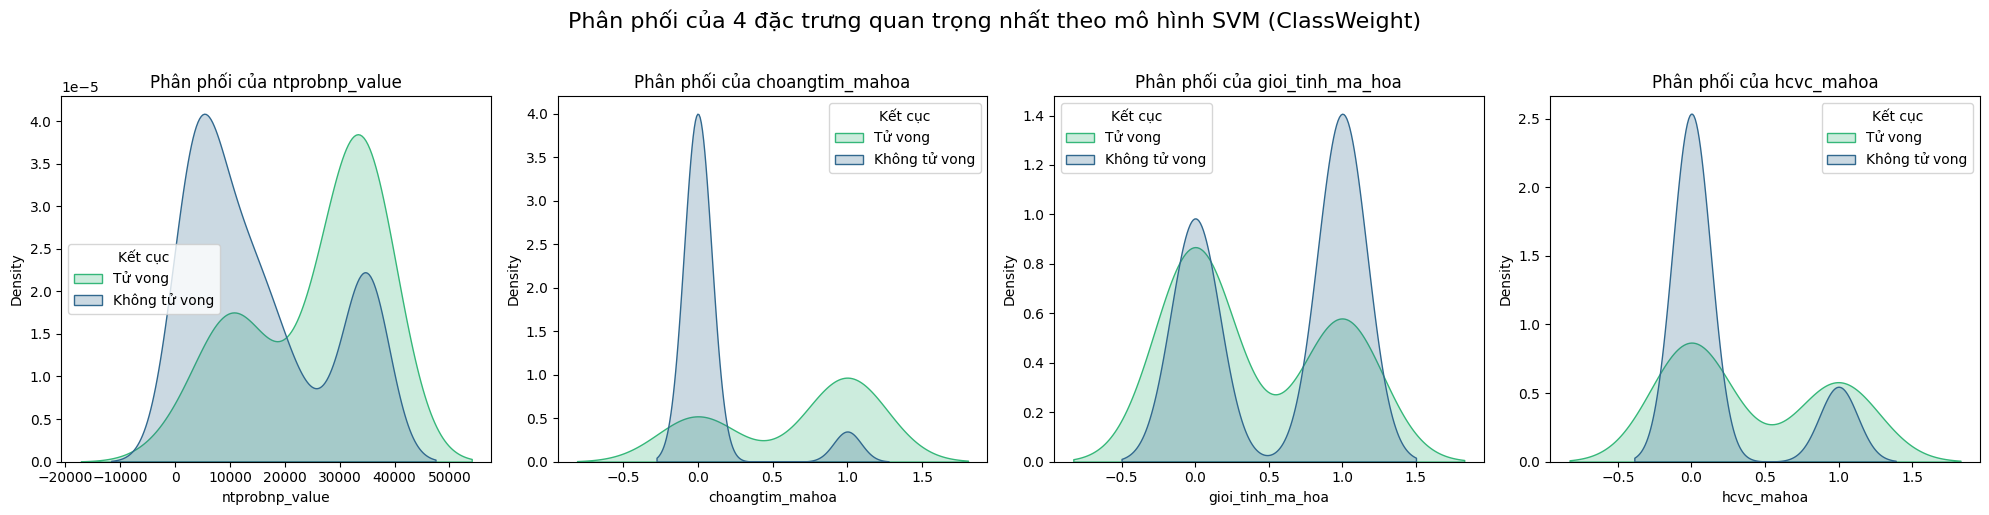


------------------------------ XGBOOST (CLASSWEIGHT) ------------------------------
Top 10 đặc trưng quan trọng nhất:
        Feature  Importance
choangtim_mahoa    0.227002
    matbu_mahoa    0.181655
 suyhohap_mahoa    0.132529
 ntprobnp_value    0.102889
     Creatinine    0.076854
  Troponin_I_hs    0.069587
           HATT    0.041769
      dtd_mahoa    0.040619
         adhere    0.035343
            bmi    0.024829


/var/folders/3s/zltsvmc54fq7vrpdxp8mypz00000gr/T/ipykernel_33734/1479282165.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


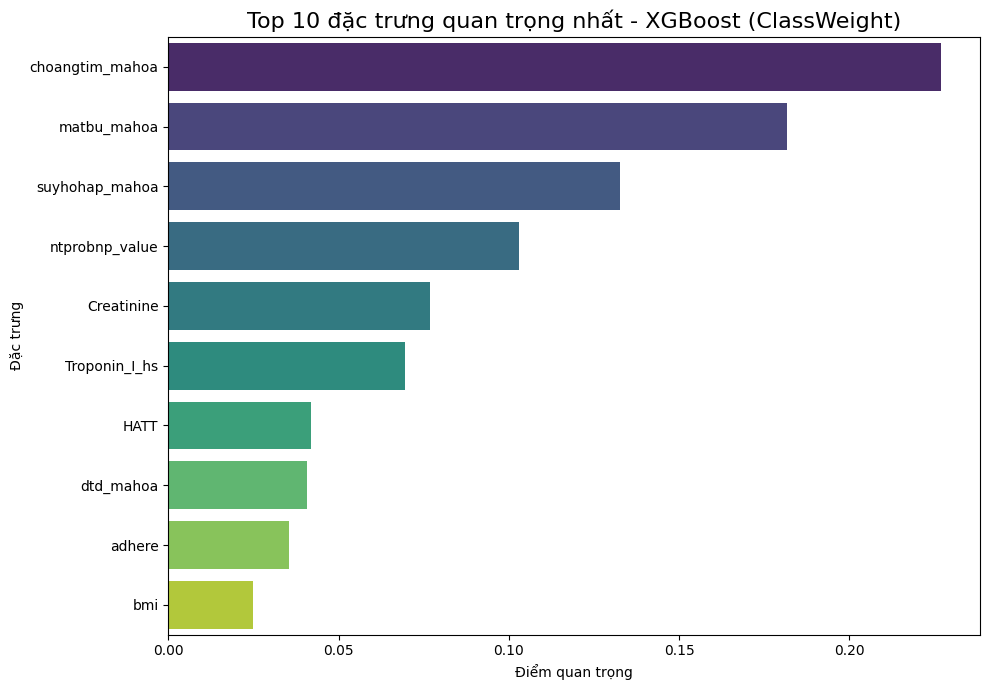

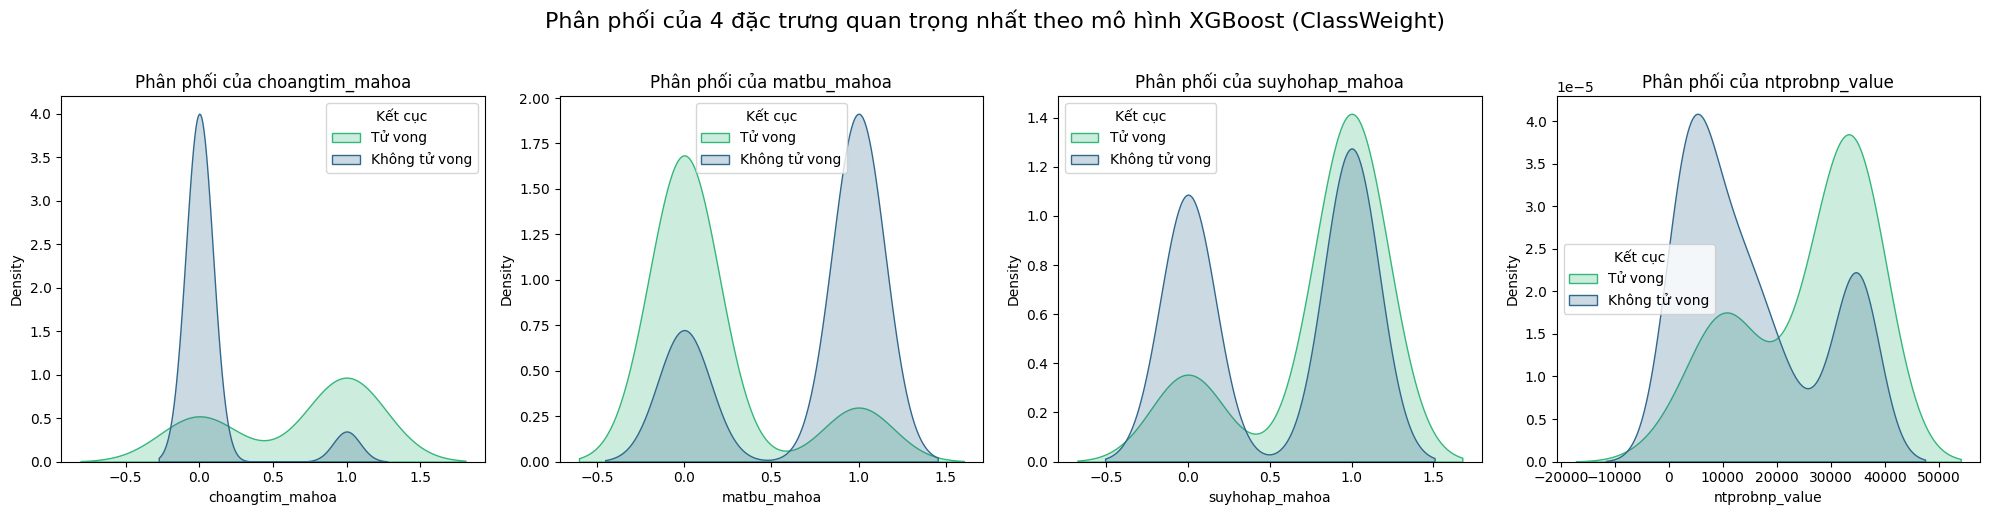


------------------------------ RF (ADASYN) ------------------------------
Top 10 đặc trưng quan trọng nhất:
        Feature  Importance
    matbu_mahoa    0.138812
choangtim_mahoa    0.132619
  Troponin_I_hs    0.121739
            AST    0.084120
           HATT    0.077627
 ntprobnp_value    0.060548
 suyhohap_mahoa    0.050138
          HATTr    0.050010
         adhere    0.049145
     Creatinine    0.046418


/var/folders/3s/zltsvmc54fq7vrpdxp8mypz00000gr/T/ipykernel_33734/1479282165.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


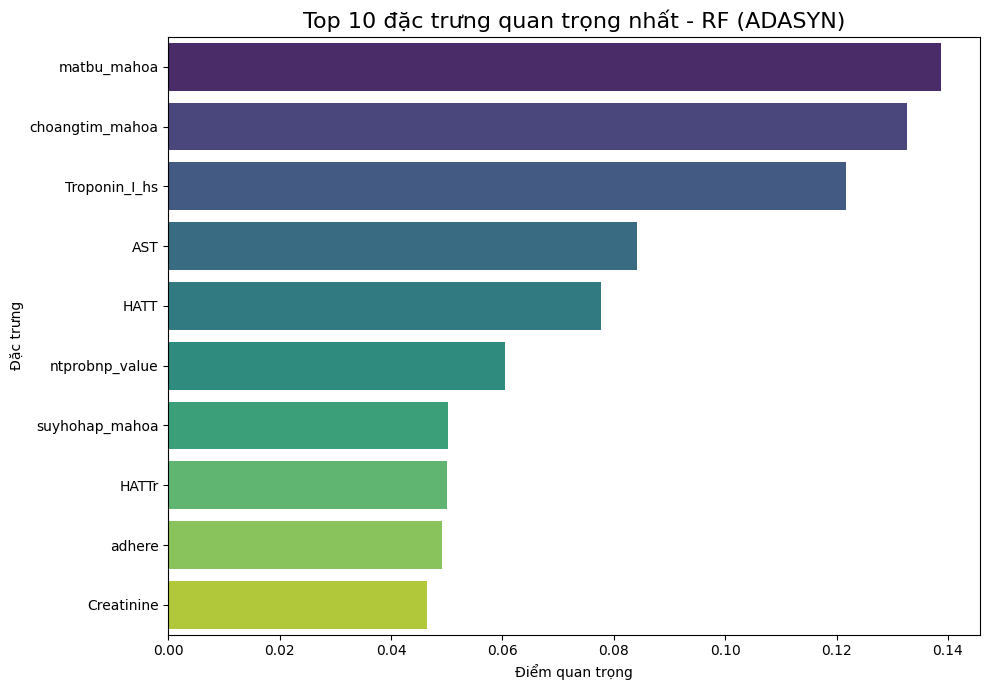

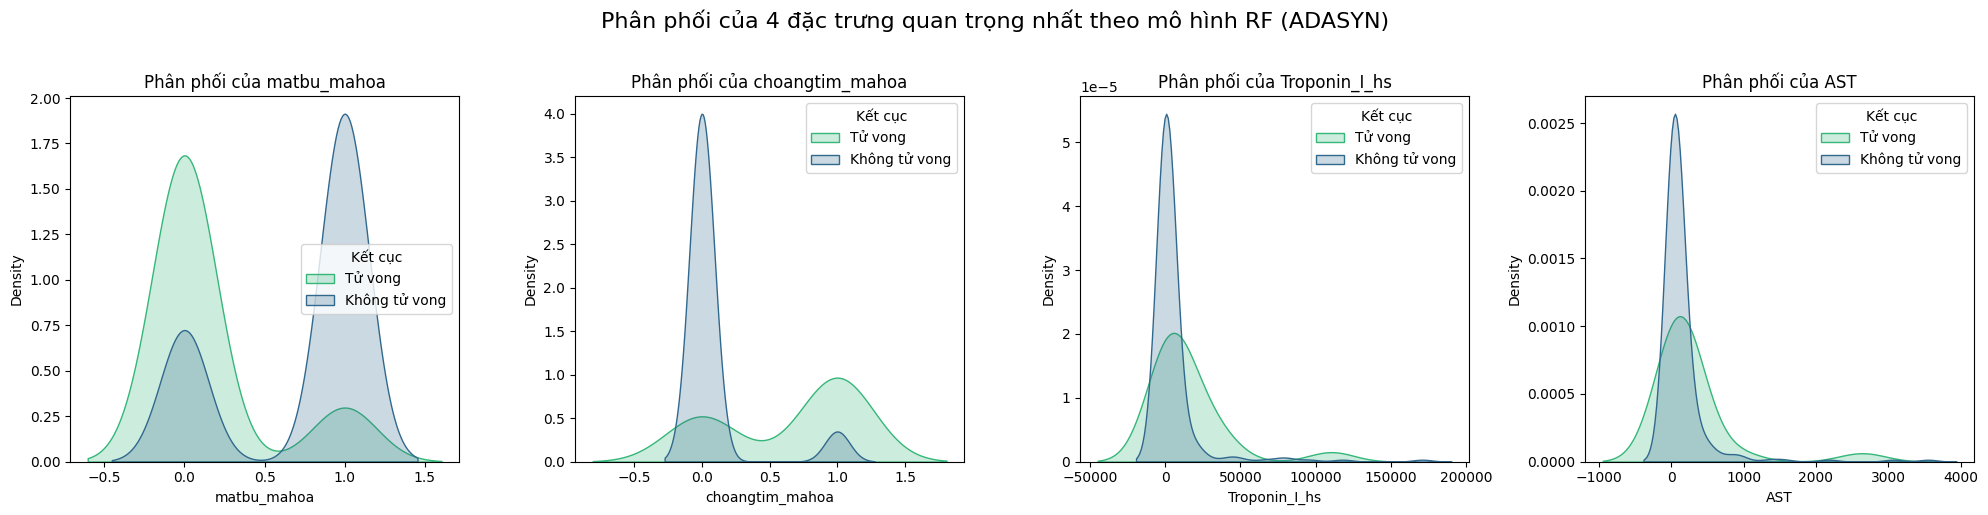


------------------------------ LOGREG (ADASYN) ------------------------------
Top 10 đặc trưng quan trọng nhất:
         Feature  Importance
  ntprobnp_value    1.518462
 choangtim_mahoa    1.130596
            HATT    0.841311
           HATTr    0.690863
  suyhohap_mahoa    0.626959
      hcvc_mahoa    0.578160
gioi_tinh_ma_hoa    0.576582
       dtd_mahoa    0.558075
               K    0.475345
          adhere    0.458161


/var/folders/3s/zltsvmc54fq7vrpdxp8mypz00000gr/T/ipykernel_33734/1479282165.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


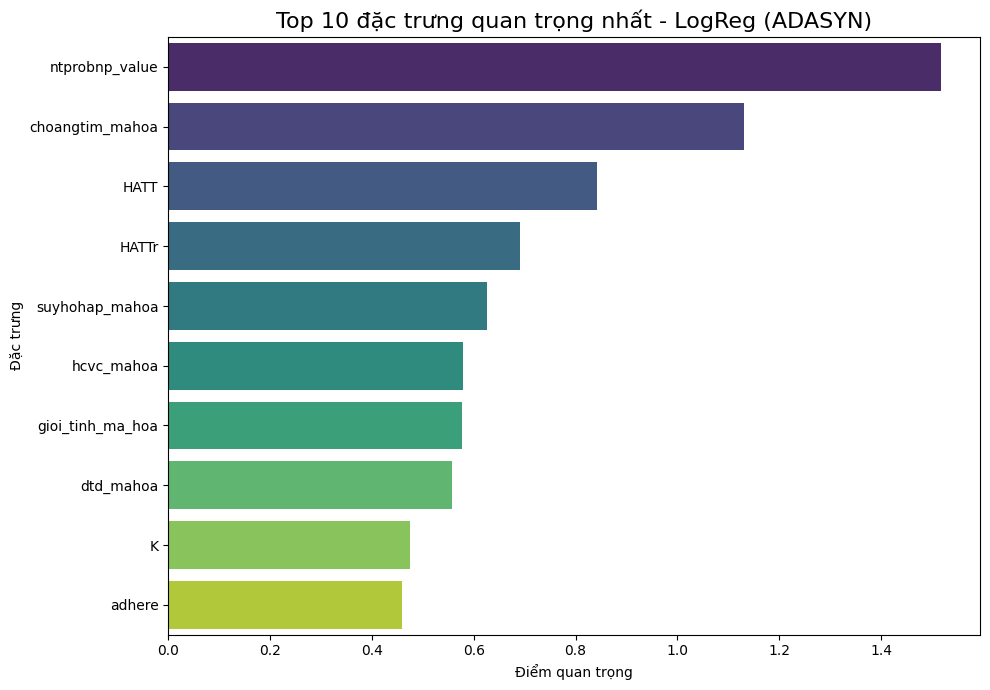

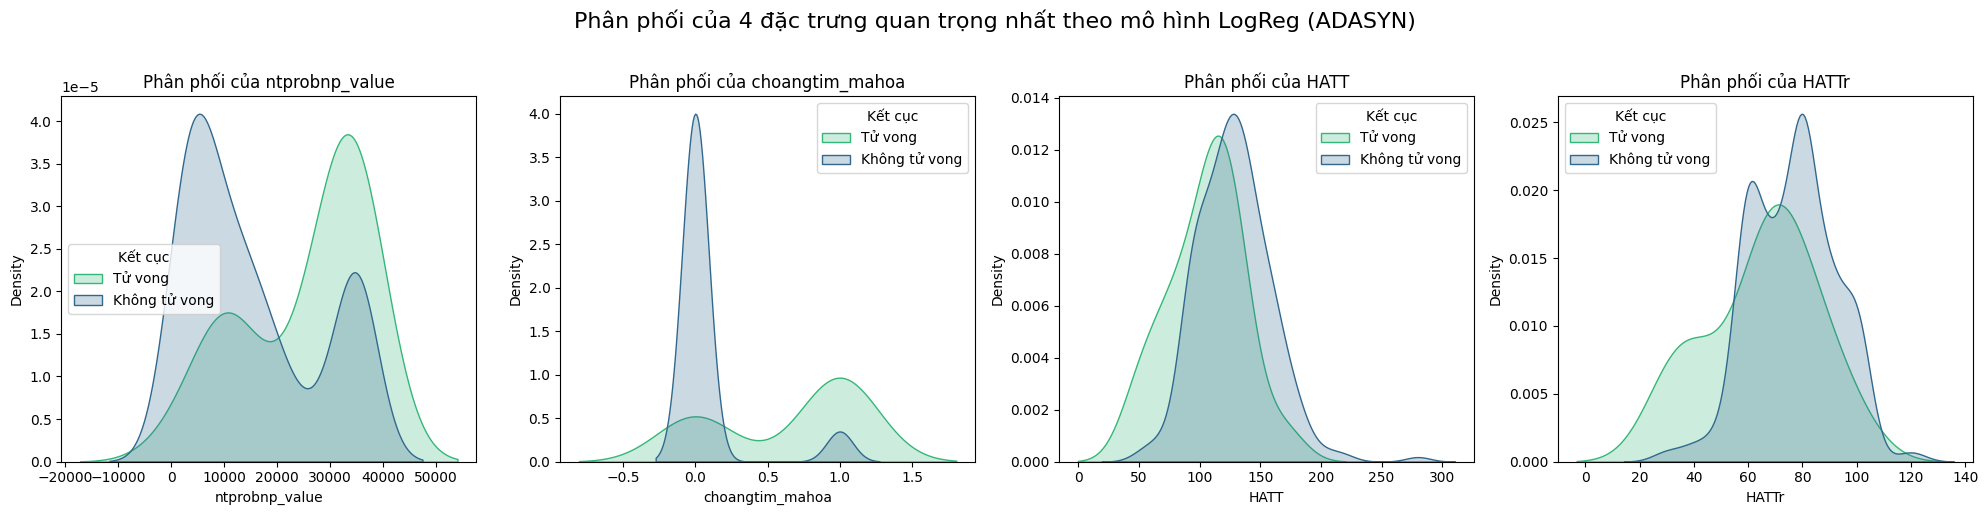


------------------------------ SVM (ADASYN) ------------------------------
Top 10 đặc trưng quan trọng nhất:
         Feature  Importance
  ntprobnp_value    1.518462
 choangtim_mahoa    1.130596
            HATT    0.841311
           HATTr    0.690863
  suyhohap_mahoa    0.626959
      hcvc_mahoa    0.578160
gioi_tinh_ma_hoa    0.576582
       dtd_mahoa    0.558075
               K    0.475345
          adhere    0.458161


/var/folders/3s/zltsvmc54fq7vrpdxp8mypz00000gr/T/ipykernel_33734/1479282165.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


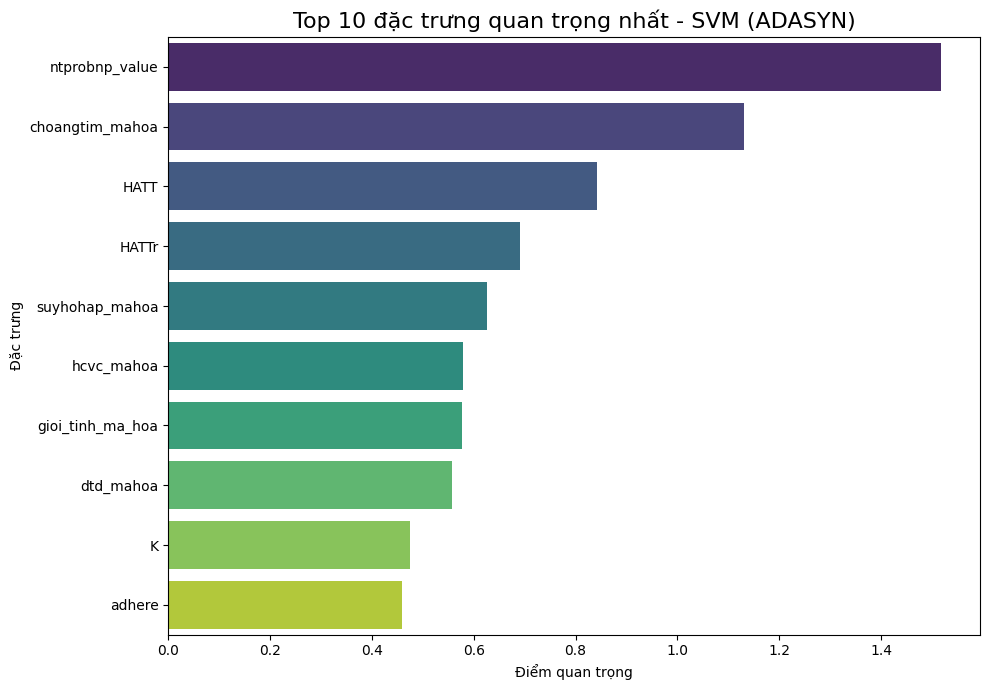

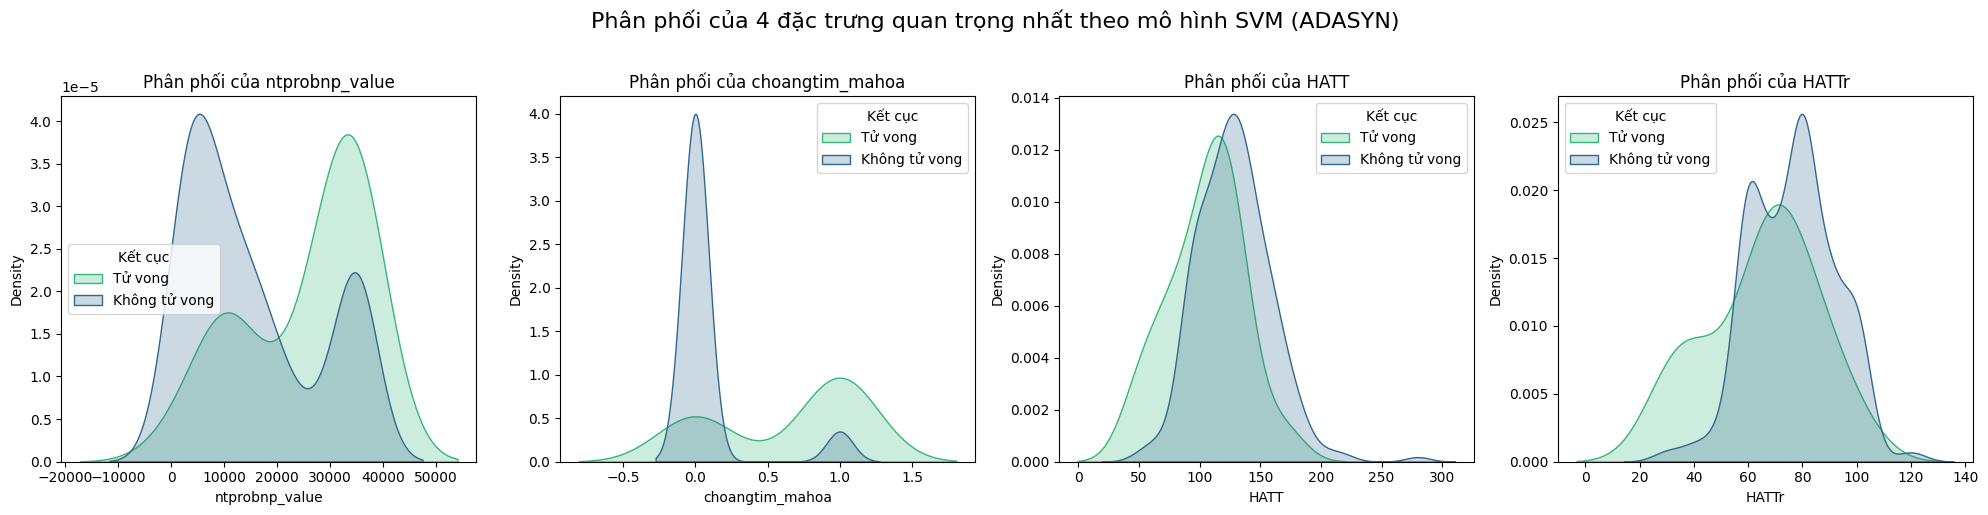


------------------------------ XGBOOST (ADASYN) ------------------------------
Top 10 đặc trưng quan trọng nhất:
        Feature  Importance
    matbu_mahoa    0.584463
choangtim_mahoa    0.064844
     hcvc_mahoa    0.062094
           HATT    0.052429
      dtd_mahoa    0.038924
 suyhohap_mahoa    0.034053
     Creatinine    0.027388
         adhere    0.022848
  Troponin_I_hs    0.022802
 ntprobnp_value    0.022260


/var/folders/3s/zltsvmc54fq7vrpdxp8mypz00000gr/T/ipykernel_33734/1479282165.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')


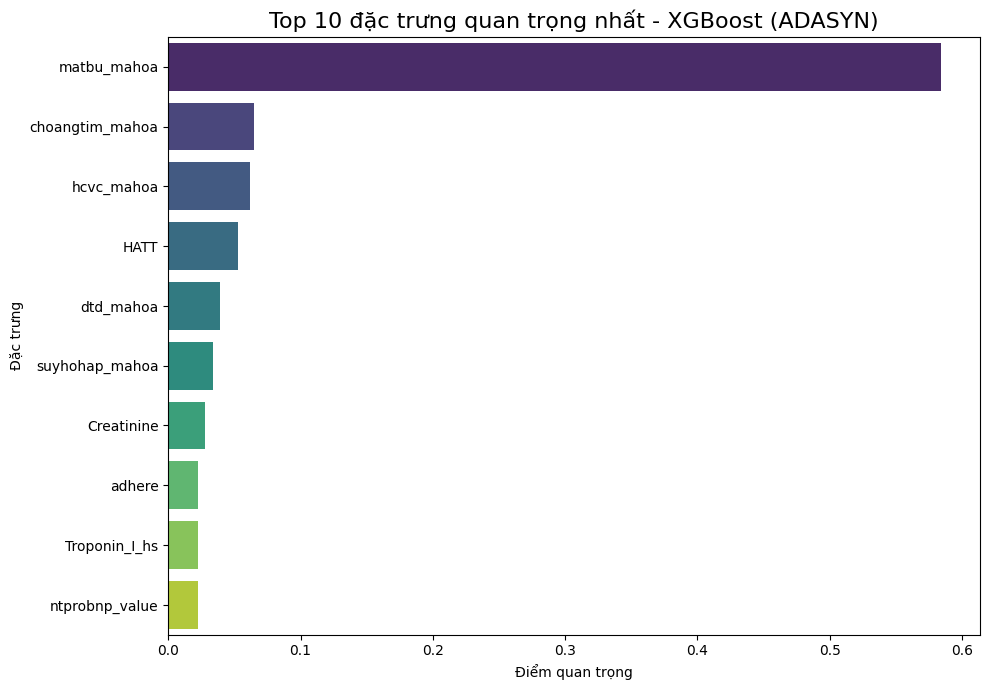

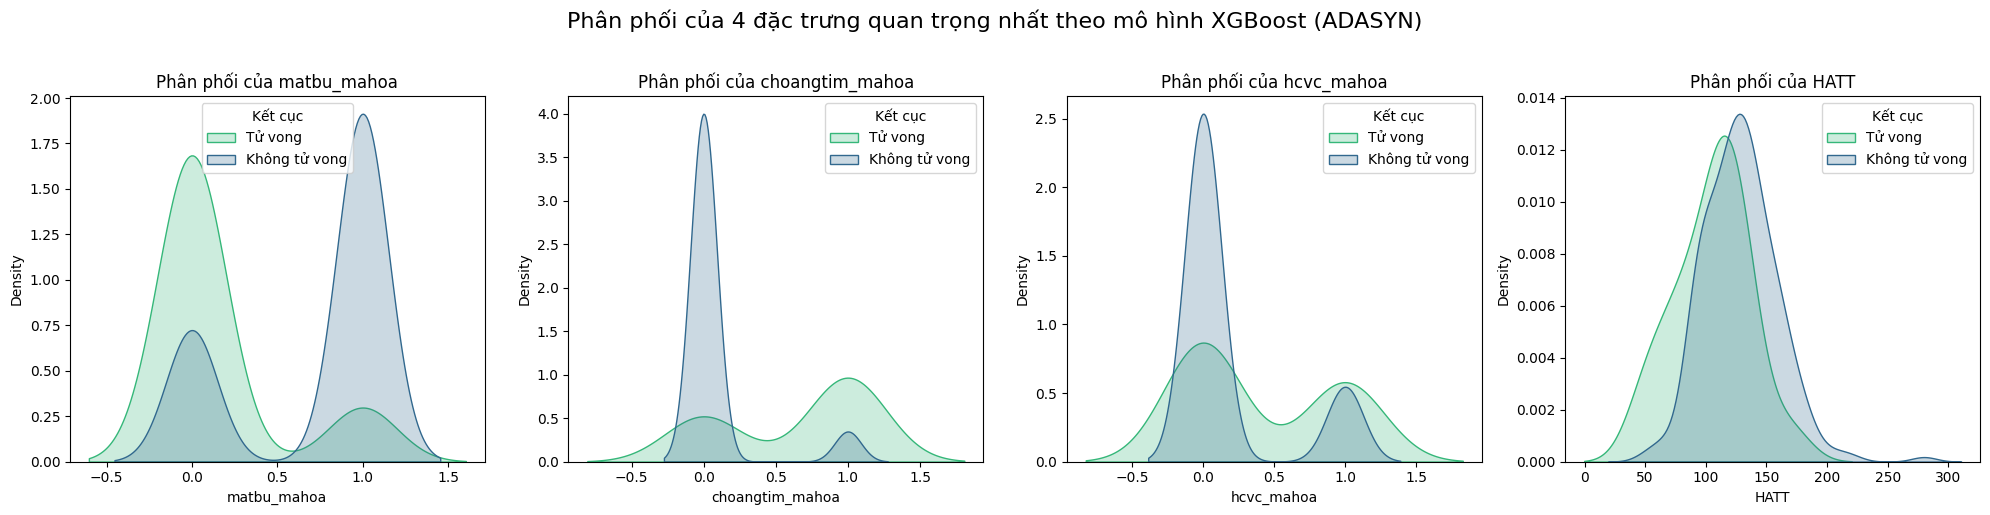

In [65]:
for model_name, result in final_results.items():
    if model_name == 'GWTG Score': continue
    print("\n" + "-"*30 + f" {model_name.upper()} " + "-"*30)
    pipeline = result['model']
    classifier = pipeline.named_steps['classifier']
    selector = pipeline.named_steps['feature_selection']
    preprocessor = pipeline.named_steps['preprocessor']
    selected_feature_names = pipeline.named_steps['feature_selection'].get_feature_names_out(X_dev_cleaned.columns)
    selected_feature_names = [name.replace('num__', '') for name in selected_feature_names]
    importances = None
    if hasattr(classifier, 'feature_importances_') and not 'XGBoost' in model_name:
        importances = classifier.feature_importances_
        feature_importance_df = pd.DataFrame({'Feature': selected_feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    elif 'XGBoost' in model_name:
        gain_importances = classifier.get_booster().get_score(importance_type='gain')
        X_dev_transformed_temp = preprocessor.transform(X_dev_cleaned)
        selected_indices = selector.get_support(indices=True)
        final_feature_names = X_dev_cleaned.columns[selected_indices]
        feature_importance_df = pd.DataFrame({
            'Feature': final_feature_names,
            'Importance': classifier.feature_importances_
        }).sort_values(by='Importance', ascending=False)
    elif hasattr(classifier, 'coef_'):
        importances = np.abs(classifier.coef_[0])
        feature_importance_df = pd.DataFrame({'Feature': selected_feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)
    if 'feature_importance_df' not in locals() or feature_importance_df is None:
        print("Không thể trích xuất độ quan trọng cho mô hình này.")
        continue
    top_10_features = feature_importance_df.head(10)
    print("Top 10 đặc trưng quan trọng nhất:")
    print(top_10_features.to_string(index=False))
    plt.figure(figsize=(10, 7))
    sns.barplot(x='Importance', y='Feature', data=top_10_features, palette='viridis')
    plt.title(f'Top 10 đặc trưng quan trọng nhất - {model_name}', fontsize=16)
    plt.xlabel('Điểm quan trọng'); plt.ylabel('Đặc trưng')
    plt.tight_layout(); plt.show()
    dev_set_for_viz = pd.concat([X_dev_cleaned, y_dev], axis=1)
    top_features = feature_importance_df['Feature'].head(4).tolist()
    plt.figure(figsize=(20, 5))
    plt.suptitle(f'Phân phối của 4 đặc trưng quan trọng nhất theo mô hình {model_name}', fontsize=16, y=1.02)
    for i, feature in enumerate(top_features):
        plt.subplot(1, len(top_features), i + 1)
        sns.kdeplot(data=dev_set_for_viz, x=feature, hue='ketcuc_mahoa', fill=True, common_norm=False, palette='viridis')
        plt.title(f'Phân phối của {feature}')
        plt.legend(title='Kết cục', labels=['Tử vong', 'Không tử vong'])
    plt.tight_layout()
    plt.show()


## 6.2. PHÂN TÍCH MA TRẬN NHẦM LẪN VÀ CHỈ SỐ (VỚI NGƯỠNG MẶC ĐỊNH 0.5)


######################### PHÂN TÍCH MÔ HÌNH: RF (CLASSWEIGHT) #########################
               precision    recall  f1-score   support

Không tử vong       0.92      1.00      0.96        76
      Tử vong       0.00      0.00      0.00         7

     accuracy                           0.92        83
    macro avg       0.46      0.50      0.48        83
 weighted avg       0.84      0.92      0.88        83



/Users/top/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/top/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/top/miniconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


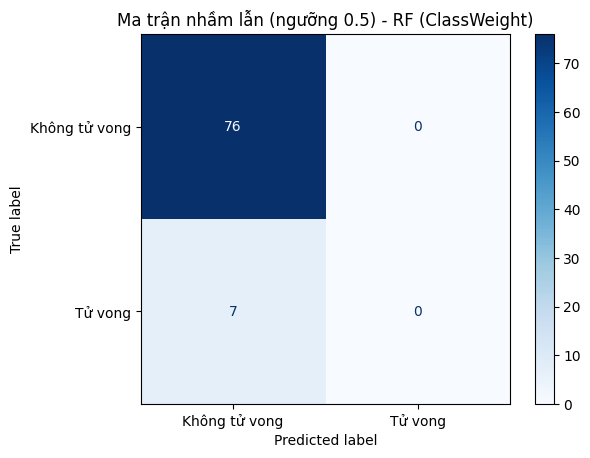


######################### PHÂN TÍCH MÔ HÌNH: LOGREG (CLASSWEIGHT) #########################
               precision    recall  f1-score   support

Không tử vong       0.98      0.78      0.87        76
      Tử vong       0.26      0.86      0.40         7

     accuracy                           0.78        83
    macro avg       0.62      0.82      0.63        83
 weighted avg       0.92      0.78      0.83        83



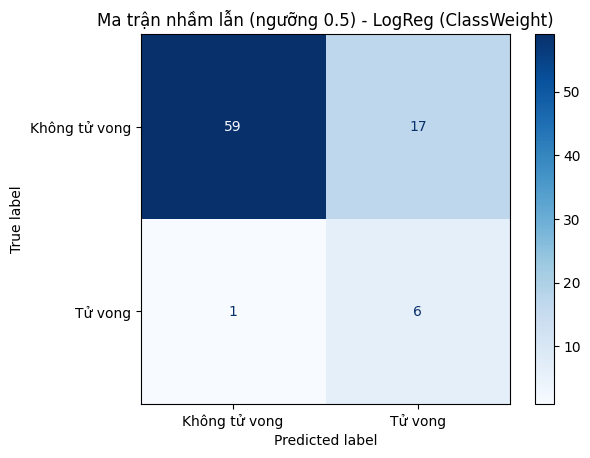


######################### PHÂN TÍCH MÔ HÌNH: SVM (CLASSWEIGHT) #########################
               precision    recall  f1-score   support

Không tử vong       0.91      0.84      0.88        76
      Tử vong       0.08      0.14      0.10         7

     accuracy                           0.78        83
    macro avg       0.50      0.49      0.49        83
 weighted avg       0.84      0.78      0.81        83



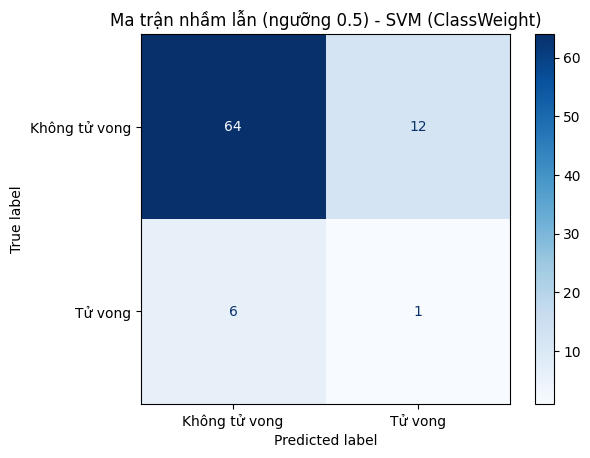


######################### PHÂN TÍCH MÔ HÌNH: XGBOOST (CLASSWEIGHT) #########################
               precision    recall  f1-score   support

Không tử vong       0.92      0.95      0.94        76
      Tử vong       0.20      0.14      0.17         7

     accuracy                           0.88        83
    macro avg       0.56      0.55      0.55        83
 weighted avg       0.86      0.88      0.87        83



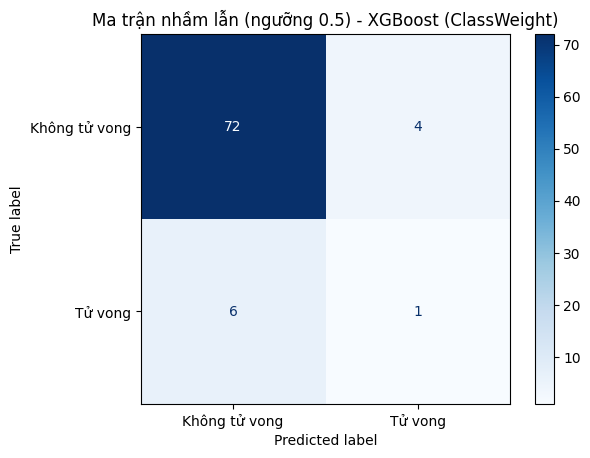


######################### PHÂN TÍCH MÔ HÌNH: RF (ADASYN) #########################
               precision    recall  f1-score   support

Không tử vong       0.93      0.92      0.93        76
      Tử vong       0.25      0.29      0.27         7

     accuracy                           0.87        83
    macro avg       0.59      0.60      0.60        83
 weighted avg       0.88      0.87      0.87        83



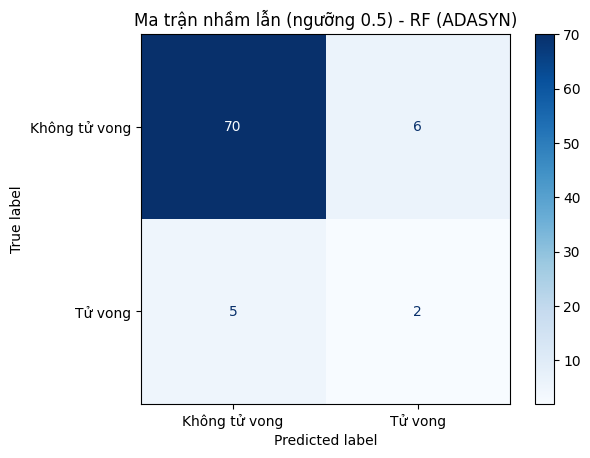


######################### PHÂN TÍCH MÔ HÌNH: LOGREG (ADASYN) #########################
               precision    recall  f1-score   support

Không tử vong       0.97      0.75      0.84        76
      Tử vong       0.21      0.71      0.32         7

     accuracy                           0.75        83
    macro avg       0.59      0.73      0.58        83
 weighted avg       0.90      0.75      0.80        83



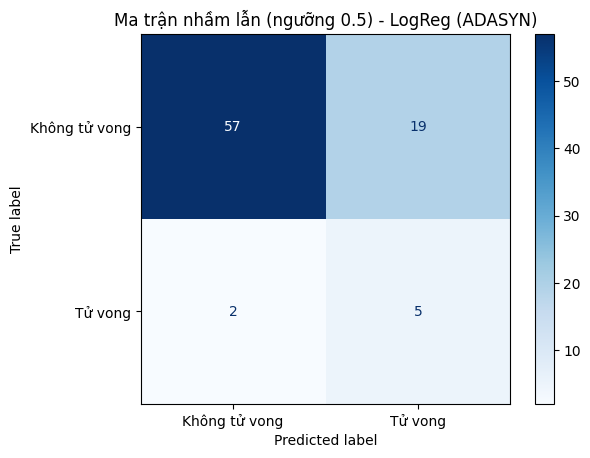


######################### PHÂN TÍCH MÔ HÌNH: SVM (ADASYN) #########################
               precision    recall  f1-score   support

Không tử vong       0.91      0.84      0.88        76
      Tử vong       0.08      0.14      0.10         7

     accuracy                           0.78        83
    macro avg       0.50      0.49      0.49        83
 weighted avg       0.84      0.78      0.81        83



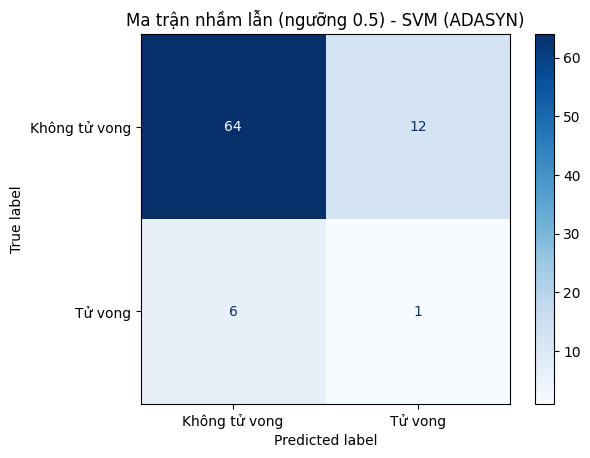


######################### PHÂN TÍCH MÔ HÌNH: XGBOOST (ADASYN) #########################
               precision    recall  f1-score   support

Không tử vong       0.93      0.89      0.91        76
      Tử vong       0.20      0.29      0.24         7

     accuracy                           0.84        83
    macro avg       0.57      0.59      0.57        83
 weighted avg       0.87      0.84      0.86        83



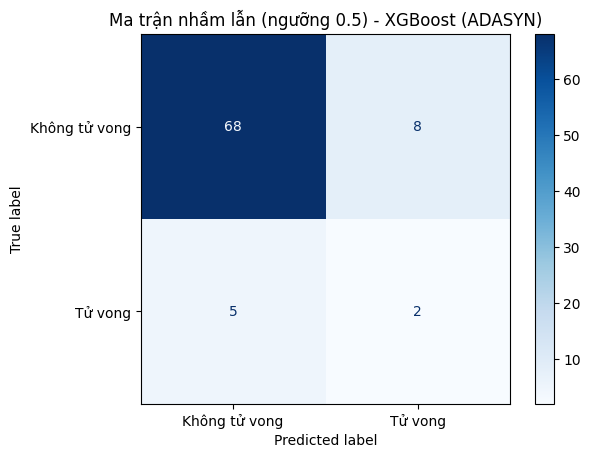

In [66]:
for model_name, result in final_results.items():
    if model_name == 'GWTG Score': continue
    pipeline = result['model']
    y_pred = pipeline.predict(X_test_cleaned)
    print("\n" + "#"*25 + f" PHÂN TÍCH MÔ HÌNH: {model_name.upper()} " + "#"*25)
    print(classification_report(y_test, y_pred, target_names=["Không tử vong", "Tử vong"]))
    cm = confusion_matrix(y_test, y_pred, labels=pipeline.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Không tử vong", "Tử vong"])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Ma trận nhầm lẫn (ngưỡng 0.5) - {model_name}'); plt.show()

## 6.3. TỐI ƯU HÓA NGƯỠNG CHO TẤT CẢ CÁC MÔ HÌNH



######################### TỐI ƯU NGƯỠNG CHO: RF (CLASSWEIGHT) #########################
Ngưỡng tối ưu (OOF): 0.1333 | PPV: 0.300 | Recall: 0.750 | Spec: 0.845 | F1: 0.429

--- Báo cáo phân loại trên tập TEST (ngưỡng từ OOF) ---
               precision    recall  f1-score   support

Không tử vong       0.97      0.78      0.86        76
      Tử vong       0.23      0.71      0.34         7

     accuracy                           0.77        83
    macro avg       0.60      0.75      0.60        83
 weighted avg       0.90      0.77      0.82        83



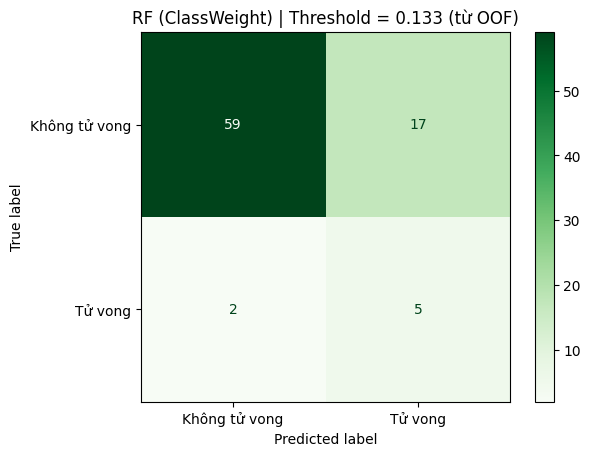


######################### TỐI ƯU NGƯỠNG CHO: LOGREG (CLASSWEIGHT) #########################
Ngưỡng tối ưu (OOF): 0.1766 | PPV: 0.149 | Recall: 0.700 | Spec: 0.646 | F1: 0.246
⚠️  Cảnh báo: Ngưỡng OOF không thỏa đầy đủ ràng buộc (đã dùng cơ chế nới lỏng). Xem xét điều chỉnh mục tiêu hoặc hiệu chỉnh xác suất (calibration).

--- Báo cáo phân loại trên tập TEST (ngưỡng từ OOF) ---
               precision    recall  f1-score   support

Không tử vong       1.00      0.54      0.70        76
      Tử vong       0.17      1.00      0.29         7

     accuracy                           0.58        83
    macro avg       0.58      0.77      0.49        83
 weighted avg       0.93      0.58      0.67        83



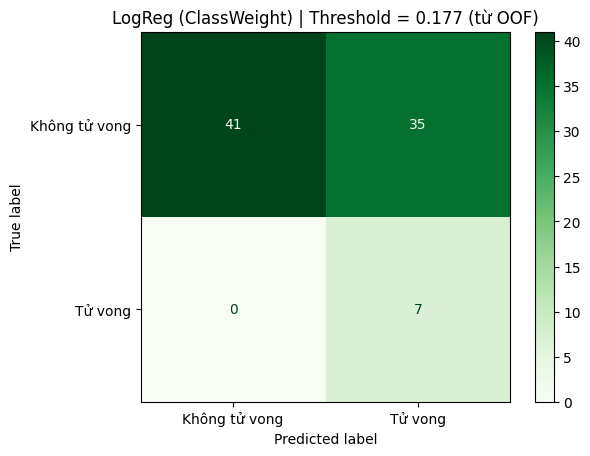


######################### TỐI ƯU NGƯỠNG CHO: SVM (CLASSWEIGHT) #########################
Ngưỡng tối ưu (OOF): 0.1102 | PPV: 0.254 | Recall: 0.750 | Spec: 0.805 | F1: 0.380

--- Báo cáo phân loại trên tập TEST (ngưỡng từ OOF) ---
               precision    recall  f1-score   support

Không tử vong       0.96      0.72      0.83        76
      Tử vong       0.19      0.71      0.30         7

     accuracy                           0.72        83
    macro avg       0.58      0.72      0.57        83
 weighted avg       0.90      0.72      0.78        83



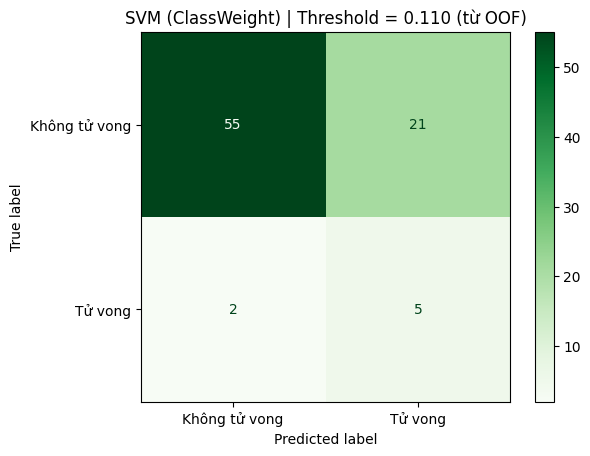


######################### TỐI ƯU NGƯỠNG CHO: XGBOOST (CLASSWEIGHT) #########################
Ngưỡng tối ưu (OOF): 0.0082 | PPV: 0.163 | Recall: 0.700 | Spec: 0.681 | F1: 0.264
⚠️  Cảnh báo: Ngưỡng OOF không thỏa đầy đủ ràng buộc (đã dùng cơ chế nới lỏng). Xem xét điều chỉnh mục tiêu hoặc hiệu chỉnh xác suất (calibration).

--- Báo cáo phân loại trên tập TEST (ngưỡng từ OOF) ---
               precision    recall  f1-score   support

Không tử vong       1.00      0.54      0.70        76
      Tử vong       0.17      1.00      0.29         7

     accuracy                           0.58        83
    macro avg       0.58      0.77      0.49        83
 weighted avg       0.93      0.58      0.67        83



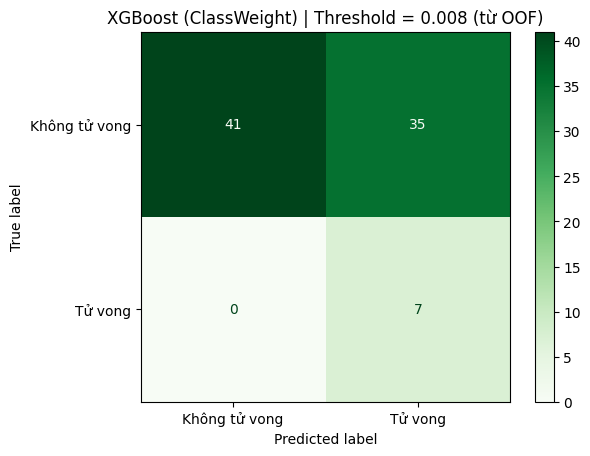


######################### TỐI ƯU NGƯỠNG CHO: RF (ADASYN) #########################
Ngưỡng tối ưu (OOF): 0.1933 | PPV: 0.246 | Recall: 0.750 | Spec: 0.796 | F1: 0.370

--- Báo cáo phân loại trên tập TEST (ngưỡng từ OOF) ---
               precision    recall  f1-score   support

Không tử vong       0.98      0.71      0.82        76
      Tử vong       0.21      0.86      0.34         7

     accuracy                           0.72        83
    macro avg       0.60      0.78      0.58        83
 weighted avg       0.92      0.72      0.78        83



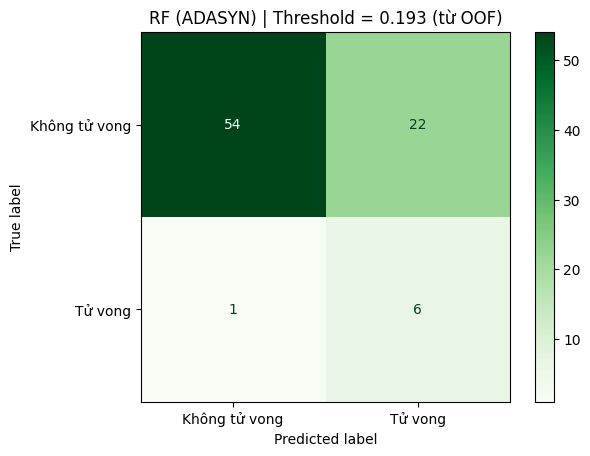


######################### TỐI ƯU NGƯỠNG CHO: LOGREG (ADASYN) #########################
Ngưỡng tối ưu (OOF): 0.2268 | PPV: 0.169 | Recall: 0.700 | Spec: 0.695 | F1: 0.272
⚠️  Cảnh báo: Ngưỡng OOF không thỏa đầy đủ ràng buộc (đã dùng cơ chế nới lỏng). Xem xét điều chỉnh mục tiêu hoặc hiệu chỉnh xác suất (calibration).

--- Báo cáo phân loại trên tập TEST (ngưỡng từ OOF) ---
               precision    recall  f1-score   support

Không tử vong       0.98      0.66      0.79        76
      Tử vong       0.19      0.86      0.31         7

     accuracy                           0.67        83
    macro avg       0.58      0.76      0.55        83
 weighted avg       0.91      0.67      0.75        83



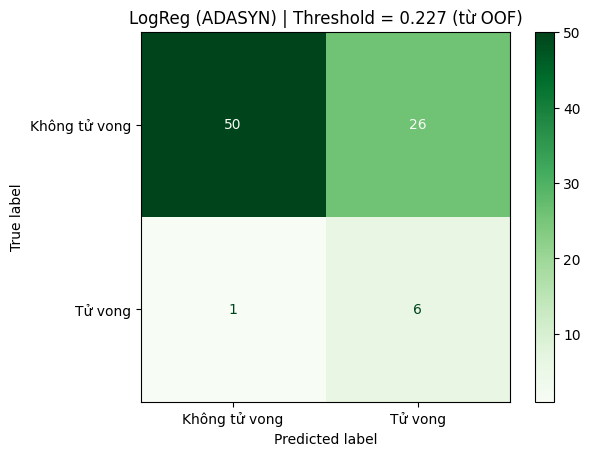


######################### TỐI ƯU NGƯỠNG CHO: SVM (ADASYN) #########################
Ngưỡng tối ưu (OOF): 0.0156 | PPV: 0.212 | Recall: 0.700 | Spec: 0.770 | F1: 0.326
⚠️  Cảnh báo: Ngưỡng OOF không thỏa đầy đủ ràng buộc (đã dùng cơ chế nới lỏng). Xem xét điều chỉnh mục tiêu hoặc hiệu chỉnh xác suất (calibration).

--- Báo cáo phân loại trên tập TEST (ngưỡng từ OOF) ---
               precision    recall  f1-score   support

Không tử vong       0.93      0.72      0.81        76
      Tử vong       0.12      0.43      0.19         7

     accuracy                           0.70        83
    macro avg       0.53      0.58      0.50        83
 weighted avg       0.86      0.70      0.76        83



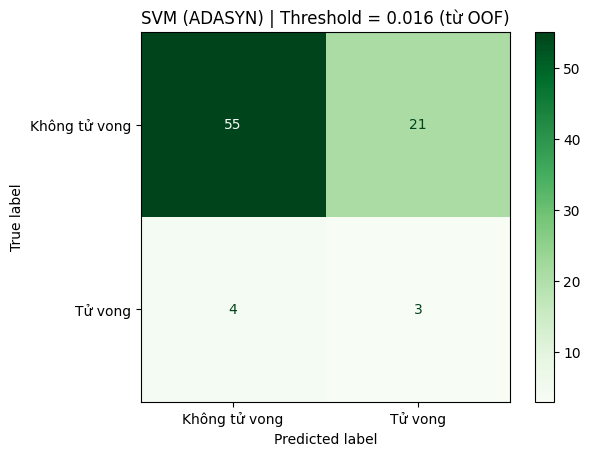


######################### TỐI ƯU NGƯỠNG CHO: XGBOOST (ADASYN) #########################
Ngưỡng tối ưu (OOF): 0.0561 | PPV: 0.263 | Recall: 0.750 | Spec: 0.814 | F1: 0.390

--- Báo cáo phân loại trên tập TEST (ngưỡng từ OOF) ---
               precision    recall  f1-score   support

Không tử vong       0.95      0.75      0.84        76
      Tử vong       0.17      0.57      0.27         7

     accuracy                           0.73        83
    macro avg       0.56      0.66      0.55        83
 weighted avg       0.88      0.73      0.79        83



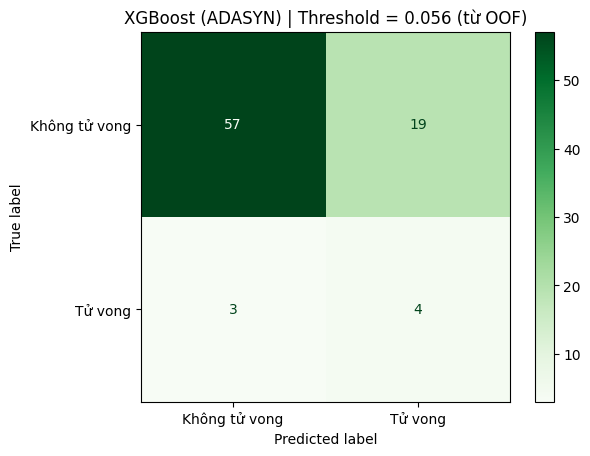

In [67]:
MIN_RECALL_TARGET = 0.70
MIN_PPV_TARGET   = 0.2
SEED = 40

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

def _metrics_from_cm(tn, fp, fn, tp):
    recall = tp / (tp + fn + 1e-12)
    spec   = tn / (tn + fp + 1e-12)
    prec   = tp / (tp + fp + 1e-12)
    f1     = 2 * prec * recall / (prec + recall + 1e-12)
    return prec, recall, spec, f1

def pick_threshold_with_constraints(y_true, proba,
                                    min_recall=0.80,
                                    min_spec=0.20,
                                    min_ppv=None):
    # Lấy toàn bộ ngưỡng ứng với các giá trị proba duy nhất + hai biên
    thresholds = np.r_[0.0 - 1e-12, np.unique(proba), 1.0 + 1e-12]

    best_thr, best_f1, best_tuple = None, -1.0, None

    for thr in thresholds:
        y_pred = (proba >= thr).astype(int)
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
        prec, rec, spec, f1 = _metrics_from_cm(tn, fp, fn, tp)

        ok = (rec >= min_recall) and (spec >= min_spec)
        if min_ppv is not None:
            ok = ok and (prec >= min_ppv)

        if ok and f1 > best_f1:
            best_thr, best_f1 = thr, f1
            best_tuple = (prec, rec, spec, f1)

    # Nếu không có ngưỡng thỏa tất cả ràng buộc, nới lỏng thành: max F1 với recall >= min_recall
    if best_thr is None:
        precision, recall, thr_arr = precision_recall_curve(y_true, proba)
        f1_arr = 2 * precision[:-1] * recall[:-1] / (precision[:-1] + recall[:-1] + 1e-12)
        mask = recall[:-1] >= min_recall
        if np.any(mask):
            idx = np.argmax(f1_arr[mask])
            thr = thr_arr[mask][idx]
            y_pred = (proba >= thr).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
            best_thr = thr
            best_tuple = _metrics_from_cm(tn, fp, fn, tp)
        else:
            # Fallback
            idx = np.argmax(f1_arr)
            best_thr = thr_arr[idx]
            y_pred = (proba >= best_thr).astype(int)
            tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0,1]).ravel()
            best_tuple = _metrics_from_cm(tn, fp, fn, tp)

    return float(best_thr), best_tuple

for name, pipeline in models.items():
    if name == 'GWTG Score':
        continue
    print("\n" + "#"*25 + f" TỐI ƯU NGƯỠNG CHO: {name.upper()} " + "#"*25)

    # OOF proba
    oof_proba = np.zeros(len(y_dev))
    for tr_idx, va_idx in skf.split(X_dev_cleaned, y_dev):
        X_tr, X_va = X_dev_cleaned.iloc[tr_idx], X_dev_cleaned.iloc[va_idx]
        y_tr, y_va = y_dev.iloc[tr_idx], y_dev.iloc[va_idx]
        pipeline.fit(X_tr, y_tr)
        oof_proba[va_idx] = pipeline.predict_proba(X_va)[:, 1]

    # Chọn ngưỡng trên OOF
    best_threshold, (ppv_oof, rec_oof, spec_oof, f1_oof) = pick_threshold_with_constraints(
        y_dev.values, oof_proba,
        min_recall=MIN_RECALL_TARGET,
        min_spec=MIN_PPV_TARGET,
        min_ppv=MIN_PPV_TARGET
    )
    print(f"Ngưỡng tối ưu (OOF): {best_threshold:.4f} | PPV: {ppv_oof:.3f} | Recall: {rec_oof:.3f} | Spec: {spec_oof:.3f} | F1: {f1_oof:.3f}")
    if (rec_oof < MIN_RECALL_TARGET) or (spec_oof < MIN_PPV_TARGET) or (MIN_PPV_TARGET and ppv_oof < MIN_PPV_TARGET):
        print("⚠️  Cảnh báo: Ngưỡng OOF không thỏa đầy đủ ràng buộc (đã dùng cơ chế nới lỏng). Xem xét điều chỉnh mục tiêu hoặc hiệu chỉnh xác suất (calibration).")

    # Huấn luyện lại trên toàn bộ dev
    pipeline.fit(X_dev_cleaned, y_dev)

    # Đánh giá test với ngưỡng tối ưu từ OOF
    y_proba_test = pipeline.predict_proba(X_test_cleaned)[:, 1]
    y_pred_test  = (y_proba_test >= best_threshold).astype(int)

    print("\n--- Báo cáo phân loại trên tập TEST (ngưỡng từ OOF) ---")
    print(classification_report(y_test, y_pred_test,
          target_names=["Không tử vong", "Tử vong"], zero_division=0))

    cm_new = confusion_matrix(y_test, y_pred_test, labels=[0,1])
    disp_new = ConfusionMatrixDisplay(confusion_matrix=cm_new,
                                      display_labels=["Không tử vong", "Tử vong"])
    disp_new.plot(cmap=plt.cm.Greens)
    plt.title(f'{name} | Threshold = {best_threshold:.3f} (từ OOF)')
    plt.show()


######################### TỐI ƯU NGƯỠNG CHO: GWTG-HF #########################
Ngưỡng tối ưu (DEV) GWTG-HF: 44.0000 | PPV: 0.182 | Recall: 0.800 | Spec: 0.681 | F1: 0.296
⚠️  Cảnh báo: GWTG-HF không thỏa đầy đủ ràng buộc (đã dùng cơ chế nới lỏng).

--- Báo cáo phân loại trên tập TEST (ngưỡng từ DEV) ---
               precision    recall  f1-score   support

Không tử vong       0.94      0.64      0.77        76
      Tử vong       0.13      0.57      0.21         7

     accuracy                           0.64        83
    macro avg       0.54      0.61      0.49        83
 weighted avg       0.87      0.64      0.72        83



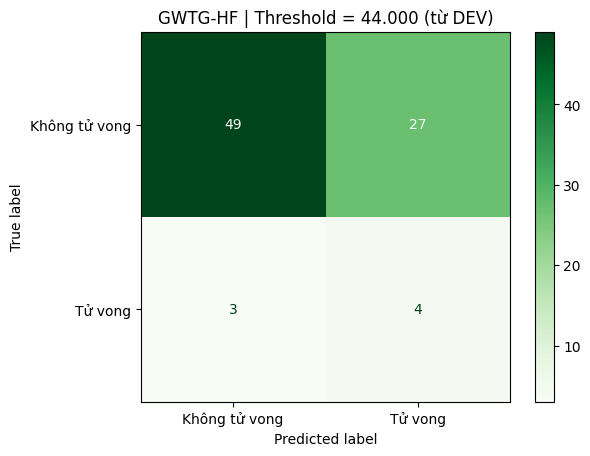

In [68]:
# ================== THÊM NGƯỠNG CHO GWTG-HF ==================
print("\n" + "#"*25 + " TỐI ƯU NGƯỠNG CHO: GWTG-HF " + "#"*25)

# Ở đây giả sử bạn đã có xác suất từ GWTG-HF trên DEV và TEST
# biến: y_scores_gwtg_train (DEV), y_scores_gwtg_test (TEST)

# Chọn ngưỡng trên DEV (OOF analog)
best_threshold_gwtg, (ppv_gwtg, rec_gwtg, spec_gwtg, f1_gwtg) = pick_threshold_with_constraints(
    y_dev.values, y_scores_gwtg_train,
    min_recall=MIN_RECALL_TARGET,
    min_spec=MIN_PPV_TARGET,
    min_ppv=MIN_PPV_TARGET
)

print(f"Ngưỡng tối ưu (DEV) GWTG-HF: {best_threshold_gwtg:.4f} "
      f"| PPV: {ppv_gwtg:.3f} | Recall: {rec_gwtg:.3f} | Spec: {spec_gwtg:.3f} | F1: {f1_gwtg:.3f}")
if (rec_gwtg < MIN_RECALL_TARGET) or (spec_gwtg < MIN_PPV_TARGET) or (MIN_PPV_TARGET and ppv_gwtg < MIN_PPV_TARGET):
    print("⚠️  Cảnh báo: GWTG-HF không thỏa đầy đủ ràng buộc (đã dùng cơ chế nới lỏng).")

# Đánh giá trên TEST với ngưỡng tối ưu
y_pred_gwtg_test = (y_scores_gwtg_test >= best_threshold_gwtg).astype(int)

print("\n--- Báo cáo phân loại trên tập TEST (ngưỡng từ DEV) ---")
print(classification_report(y_test, y_pred_gwtg_test,
      target_names=["Không tử vong", "Tử vong"], zero_division=0))

cm_gwtg = confusion_matrix(y_test, y_pred_gwtg_test, labels=[0,1])
disp_gwtg = ConfusionMatrixDisplay(confusion_matrix=cm_gwtg,
                                   display_labels=["Không tử vong", "Tử vong"])
disp_gwtg.plot(cmap=plt.cm.Greens)
plt.title(f'GWTG-HF | Threshold = {best_threshold_gwtg:.3f} (từ DEV)')
plt.show()


## 6.4 DIỄN GIẢI MÔ HÌNH SVM

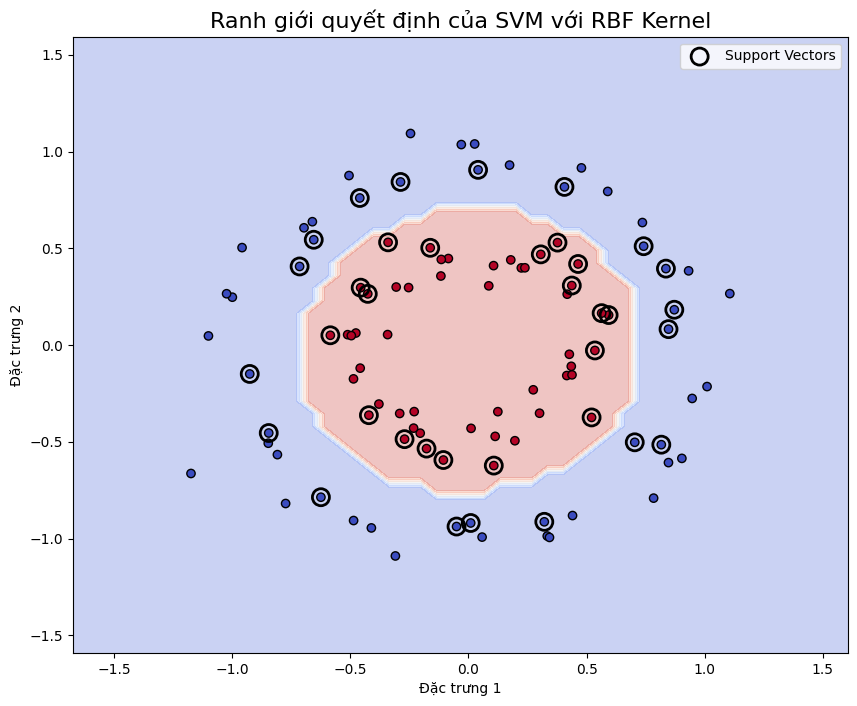


Diễn giải biểu đồ:
- Các vùng màu nền (xanh/đỏ nhạt) thể hiện khu vực mà mô hình sẽ dự đoán cho mỗi lớp.
- Bạn có thể thấy ranh giới không phải là một đường thẳng mà là một đường cong, bao quanh lớp bên trong.
- Đây chính là sức mạnh của RBF kernel: tìm ra các mối quan hệ phức tạp mà các mô hình tuyến tính bỏ lỡ.
- Các điểm được khoanh tròn đen chính là các 'support vectors', những điểm dữ liệu quan trọng nhất mà mô hình dựa vào để xác định ranh giới.


In [69]:
X_viz, y_viz = make_circles(n_samples=100, factor=0.5, noise=0.1, random_state=SEED)

svm_rbf = svm.SVC(kernel='rbf', gamma=1, C=1.0).fit(X_viz, y_viz)

xx, yy = np.meshgrid(np.linspace(X_viz[:, 0].min() - 0.5, X_viz[:, 0].max() + 0.5, 50),
                     np.linspace(X_viz[:, 1].min() - 0.5, X_viz[:, 1].max() + 0.5, 50))
Z = svm_rbf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))
plt.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)

plt.scatter(X_viz[:, 0], X_viz[:, 1], c=y_viz, cmap=plt.cm.coolwarm, edgecolors='k')

plt.scatter(svm_rbf.support_vectors_[:, 0], svm_rbf.support_vectors_[:, 1],
            s=150, facecolors='none', edgecolors='k', linewidth=2, label='Support Vectors')

plt.title('Ranh giới quyết định của SVM với RBF Kernel', fontsize=16)
plt.xlabel('Đặc trưng 1')
plt.ylabel('Đặc trưng 2')
plt.legend()
plt.axis('tight')
plt.show()

print("\nDiễn giải biểu đồ:")
print("- Các vùng màu nền (xanh/đỏ nhạt) thể hiện khu vực mà mô hình sẽ dự đoán cho mỗi lớp.")
print("- Bạn có thể thấy ranh giới không phải là một đường thẳng mà là một đường cong, bao quanh lớp bên trong.")
print("- Đây chính là sức mạnh của RBF kernel: tìm ra các mối quan hệ phức tạp mà các mô hình tuyến tính bỏ lỡ.")
print("- Các điểm được khoanh tròn đen chính là các 'support vectors', những điểm dữ liệu quan trọng nhất mà mô hình dựa vào để xác định ranh giới.")

# PHẦN 7: PHÂN TÍCH THỐNG KÊ VÀ DIỄN GIẢI MÔ HÌNH NÂNG CAO

In [70]:
# 1. Xác định mô hình ML tốt nhất dựa trên AUC trên tập test
# results_df đã được sắp xếp giảm dần theo auc_test ở Phần 4.5
best_model_name = results_df.index[0]
best_model_pipeline = final_results[best_model_name]['model']
print(f"Mô hình Machine Learning tốt nhất được xác định là: '{best_model_name}' (AUC on Test = {results_df.iloc[0]['auc_test']:.4f})")

# 2. Lấy ra xác suất dự đoán của mô hình tốt nhất và mô hình GWTG trên tập Test
y_pred_proba_best_ml = best_model_pipeline.predict_proba(X_test_cleaned)[:, 1]
y_scores_gwtg = y_scores_gwtg_test.copy() # Đổi tên để nhất quán với code tham khảo

# 3. Lấy ra xác suất dự đoán của mô hình GWTG trên tập Train (để tính CI)
# Biến y_scores_gwtg_train đã được tạo ở Phần 2
auc_gwtg_on_train = roc_auc_score(y_dev, y_scores_gwtg_train)


def calculate_auc_ci(y_true, y_scores, n_iterations=1000, random_state=SEED):
    """
    Tính khoảng tin cậy 95% cho AUC sử dụng bootstrapping.

    Parameters:
    y_true (pd.Series): Nhãn thật.
    y_scores (np.array or pd.Series): Điểm số hoặc xác suất dự đoán.
    n_iterations (int): Số lần lặp bootstrap.

    Returns:
    tuple: (lower_bound, upper_bound)
    """
    # Đảm bảo y_scores là mảng numpy để xử lý nhất quán
    y_scores = np.asarray(y_scores)

    np.random.seed(random_state)
    n_size = len(y_true)
    auc_scores_boot = []

    # Chuyển y_true thành mảng numpy một lần để tăng tốc độ
    y_true_array = y_true.values

    for i in range(n_iterations):
        indices = resample(np.arange(n_size), n_samples=n_size, replace=True, random_state=random_state + i)

        y_true_boot = y_true_array[indices]

        # Bỏ qua những lần bootstrap không có đủ 2 lớp
        if len(np.unique(y_true_boot)) < 2:
            continue

        y_scores_boot = y_scores[indices]
        auc = roc_auc_score(y_true_boot, y_scores_boot)
        auc_scores_boot.append(auc)

    alpha = 0.95
    lower = np.percentile(auc_scores_boot, (1.0 - alpha) / 2.0 * 100)
    upper = np.percentile(auc_scores_boot, (alpha + (1.0 - alpha) / 2.0) * 100)

    return lower, upper

Mô hình Machine Learning tốt nhất được xác định là: 'RF (ADASYN)' (AUC on Test = 0.8656)


## 7.1. Tính Khoảng tin cậy 95% (95% CI) cho AUC bằng Bootstrapping

In [71]:
print("\nBắt đầu tính Khoảng tin cậy 95% cho AUC trên tập TRAIN...")
all_ci_results_train = {}

# 1. Đối với các mô hình Machine Learning
for name, result in final_results.items():
    if name == 'GWTG Score': continue
    print(f"   - Đang tính CI cho mô hình (Train): {name}...")
    y_pred_proba_train = result['model'].predict_proba(X_dev_cleaned)[:, 1]
    lower, upper = calculate_auc_ci(y_dev, y_pred_proba_train)
    all_ci_results_train[name] = {
        'auc': result['auc_train'],
        'ci_lower': lower,
        'ci_upper': upper
    }

# 2. Đối với mô hình GWTG truyền thống
print(f"   - Đang tính CI cho mô hình (Train): GWTG Score...")
lower_gwtg, upper_gwtg = calculate_auc_ci(y_dev, y_scores_gwtg_train)
all_ci_results_train['Mô hình truyền thống GWTG'] = {
    'auc': auc_gwtg_on_train,
    'ci_lower': lower_gwtg,
    'ci_upper': upper_gwtg
}

# --- In ra bảng tổng hợp kết quả trên TẬP TRAIN ---
print("\n" + "-" * 75)
print("BẢNG KẾT QUẢ AUC VÀ KHOẢNG TIN CẬY 95% TRÊN TẬP TRAIN")
print("-" * 75)
print(f"{'Mô hình':<30s} | {'AUC':<10s} | {'Khoảng tin cậy 95%':<25s}")
print("-" * 75)
sorted_results_train = sorted(all_ci_results_train.items(), key=lambda item: item[1]['auc'], reverse=True)
for name, stats in sorted_results_train:
    ci_str = f"[{stats['ci_lower']:.4f} - {stats['ci_upper']:.4f}]"
    print(f"{name:<30s} | {stats['auc']:.4f}     | {ci_str:<25s}")
print("-" * 75)


# --- Tính CI trên TẬP TEST ---
print("\nBắt đầu tính Khoảng tin cậy 95% cho AUC trên tập TEST...")
all_ci_results_test = {}

# 1. Đối với các mô hình Machine Learning
for name, result in final_results.items():
    if name == 'GWTG Score': continue
    print(f"   - Đang tính CI cho mô hình (Test): {name}...")
    y_pred_proba = result['model'].predict_proba(X_test_cleaned)[:, 1]
    lower, upper = calculate_auc_ci(y_test, y_pred_proba)
    all_ci_results_test[name] = {
        'auc': result['auc_test'],
        'ci_lower': lower,
        'ci_upper': upper
    }

# 2. Đối với mô hình GWTG truyền thống
print(f"   - Đang tính CI cho mô hình (Test): GWTG Score...")
# auc_gwtg_test đã được tính ở Phần 4.5
lower_gwtg, upper_gwtg = calculate_auc_ci(y_test, y_scores_gwtg)
all_ci_results_test['Mô hình truyền thống GWTG'] = {
    'auc': auc_gwtg_test,
    'ci_lower': lower_gwtg,
    'ci_upper': upper_gwtg
}

# --- In ra bảng tổng hợp kết quả trên TẬP TEST ---
print("\n" + "-" * 75)
print("BẢNG KẾT QUẢ AUC VÀ KHOẢNG TIN CẬY 95% TRÊN TẬP TEST")
print("-" * 75)
print(f"{'Mô hình':<30s} | {'AUC':<10s} | {'Khoảng tin cậy 95%':<25s}")
print("-" * 75)
sorted_results_test = sorted(all_ci_results_test.items(), key=lambda item: item[1]['auc'], reverse=True)
for name, stats in sorted_results_test:
    ci_str = f"[{stats['ci_lower']:.4f} - {stats['ci_upper']:.4f}]"
    print(f"{name:<30s} | {stats['auc']:.4f}     | {ci_str:<25s}")
print("-" * 75)


Bắt đầu tính Khoảng tin cậy 95% cho AUC trên tập TRAIN...
   - Đang tính CI cho mô hình (Train): RF (ClassWeight)...
   - Đang tính CI cho mô hình (Train): LogReg (ClassWeight)...
   - Đang tính CI cho mô hình (Train): SVM (ClassWeight)...
   - Đang tính CI cho mô hình (Train): XGBoost (ClassWeight)...
   - Đang tính CI cho mô hình (Train): RF (ADASYN)...
   - Đang tính CI cho mô hình (Train): LogReg (ADASYN)...
   - Đang tính CI cho mô hình (Train): SVM (ADASYN)...
   - Đang tính CI cho mô hình (Train): XGBoost (ADASYN)...
   - Đang tính CI cho mô hình (Train): GWTG Score...

---------------------------------------------------------------------------
BẢNG KẾT QUẢ AUC VÀ KHOẢNG TIN CẬY 95% TRÊN TẬP TRAIN
---------------------------------------------------------------------------
Mô hình                        | AUC        | Khoảng tin cậy 95%       
---------------------------------------------------------------------------
RF (ClassWeight)               | 1.0000     | [1.0000 - 1.000

## 7.2. So sánh thống kê AUC (Mô hình ML tốt nhất vs. Mô hình GWTG)

In [72]:
n_iterations = 2000
n_size = len(y_test)
y_test_array = y_test.values
y_scores_gwtg_array = y_scores_gwtg_test.values

print(f"{'So sánh cặp mô hình':<40} | {'Hiệu AUC (ML - GWTG)':<25} | {'95% CI của hiệu':<25} | {'P-value':<10}")
print("-" * 110)

# Lặp qua tất cả các mô hình ML để so sánh với GWTG
ml_models = {k: v for k, v in final_results.items() if k != 'GWTG Score'}

for name, result in ml_models.items():
    y_pred_proba_ml = result['model'].predict_proba(X_test_cleaned)[:, 1]
    auc_diffs = []

    for i in range(n_iterations):
        indices = resample(np.arange(n_size), n_samples=n_size, replace=True, random_state=SEED + i)
        y_true_boot = y_test_array[indices]
        if len(np.unique(y_true_boot)) < 2: continue

        auc_ml = roc_auc_score(y_true_boot, y_pred_proba_ml[indices])
        auc_gwtg_boot = roc_auc_score(y_true_boot, y_scores_gwtg_array[indices])
        auc_diffs.append(auc_ml - auc_gwtg_boot)

    mean_diff = np.mean(auc_diffs)
    lower_bound_diff = np.percentile(auc_diffs, 2.5)
    upper_bound_diff = np.percentile(auc_diffs, 97.5)
    p_value = (np.sum(np.array(auc_diffs) <= 0) / len(auc_diffs)) * 2 if mean_diff > 0 else (np.sum(np.array(auc_diffs) >= 0) / len(auc_diffs)) * 2

    comparison_name = f"{name} vs. GWTG"
    ci_str = f"[{lower_bound_diff:.4f}, {upper_bound_diff:.4f}]"
    print(f"{comparison_name:<40} | {mean_diff:<25.4f} | {ci_str:<25} | {p_value:<10.4f}")

print("-" * 110)

So sánh cặp mô hình                      | Hiệu AUC (ML - GWTG)      | 95% CI của hiệu           | P-value   
--------------------------------------------------------------------------------------------------------------
RF (ClassWeight) vs. GWTG                | 0.2068                    | [0.0192, 0.4109]          | 0.0310    
LogReg (ClassWeight) vs. GWTG            | 0.1741                    | [-0.0583, 0.4408]         | 0.1462    
SVM (ClassWeight) vs. GWTG               | 0.0892                    | [-0.1245, 0.3499]         | 0.4617    
XGBoost (ClassWeight) vs. GWTG           | 0.2182                    | [0.0345, 0.4333]          | 0.0180    
RF (ADASYN) vs. GWTG                     | 0.2274                    | [0.0225, 0.4564]          | 0.0260    
LogReg (ADASYN) vs. GWTG                 | 0.1430                    | [-0.0900, 0.4198]         | 0.2544    
SVM (ADASYN) vs. GWTG                    | 0.0589                    | [-0.1494, 0.3167]         | 0.6720    
XGBoost (

# PHẦN 8: PHÂN TÍCH HỆ SỐ CỦA MÔ HÌNH LOGISTIC REGRESSION


In [73]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.utils.class_weight import compute_class_weight

logreg_model_name = 'LogReg (ClassWeight)'
logreg_pipeline   = final_results[logreg_model_name]['model']
preprocessor = logreg_pipeline.named_steps['preprocessor']
selector     = logreg_pipeline.named_steps['feature_selection']

feat_names = selector.get_feature_names_out(input_features=X_dev_cleaned.columns)
feat_names = [n.replace('num__', '') for n in feat_names]

X_dev_sel = selector.transform(preprocessor.transform(X_dev_cleaned))
X_sm      = sm.add_constant(X_dev_sel)
y_sm      = y_dev.values

cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_sm)
freq_w = np.where(y_sm==1, cw[1], cw[0])

glm = sm.GLM(y_sm, X_sm, family=sm.families.Binomial(), freq_weights=freq_w)
res = glm.fit(cov_type='HC3')   # robust SE

coef   = np.asarray(res.params)[1:]
se     = np.asarray(res.bse)[1:]
p_wald = np.asarray(res.pvalues)[1:]
or_    = np.exp(coef)

ci_beta = np.asarray(res.conf_int(alpha=0.05))  # (k,2), gồm intercept ở hàng 0
ci_beta = ci_beta[1:, :]                        # bỏ intercept
or_ci   = np.exp(ci_beta)                       # cùng shape (k-1,2)

summary_df = pd.DataFrame({
    "Feature": feat_names,
    "Coefficient": coef,
    "SE_robust": se,
    "OR": or_,
    "OR_CI_2.5%": or_ci[:, 0],
    "OR_CI_97.5%": or_ci[:, 1],
    "P_Wald": p_wald
}).sort_values("P_Wald")

print(summary_df.to_string(index=False))



         Feature  Coefficient  SE_robust       OR  OR_CI_2.5%  OR_CI_97.5%   P_Wald
 choangtim_mahoa     1.178986   0.255212 3.251075    1.971469     5.361226 0.000004
  ntprobnp_value     1.324151   0.336339 3.758991    1.944369     7.267147 0.000083
gioi_tinh_ma_hoa    -0.608197   0.276270 0.544331    0.316740     0.935459 0.027703
      Creatinine    -0.382027   0.216408 0.682476    0.446561     1.043025 0.077512
      hcvc_mahoa     0.545436   0.310774 1.725360    0.938315     3.172569 0.079244
  suyhohap_mahoa     0.397007   0.236201 1.487366    0.936187     2.363049 0.092802
          adhere     0.510682   0.329969 1.666427    0.872802     3.181680 0.121703
       dtd_mahoa    -0.450736   0.291977 0.637159    0.359514     1.129222 0.122652
             bmi     0.404448   0.280146 1.498475    0.865343     2.594839 0.148823
               K    -0.359048   0.282421 0.698341    0.401486     1.214687 0.203614
            HATT    -0.466767   0.381903 0.627026    0.296626     1.325445 0

# PHẦN 10: MA TRẬN SO SÁNH ĐỘ QUAN TRỌNG CỦA ĐẶC TRƯNG


Tính toán ma trận tương quan trên tập X_dev_cleaned...


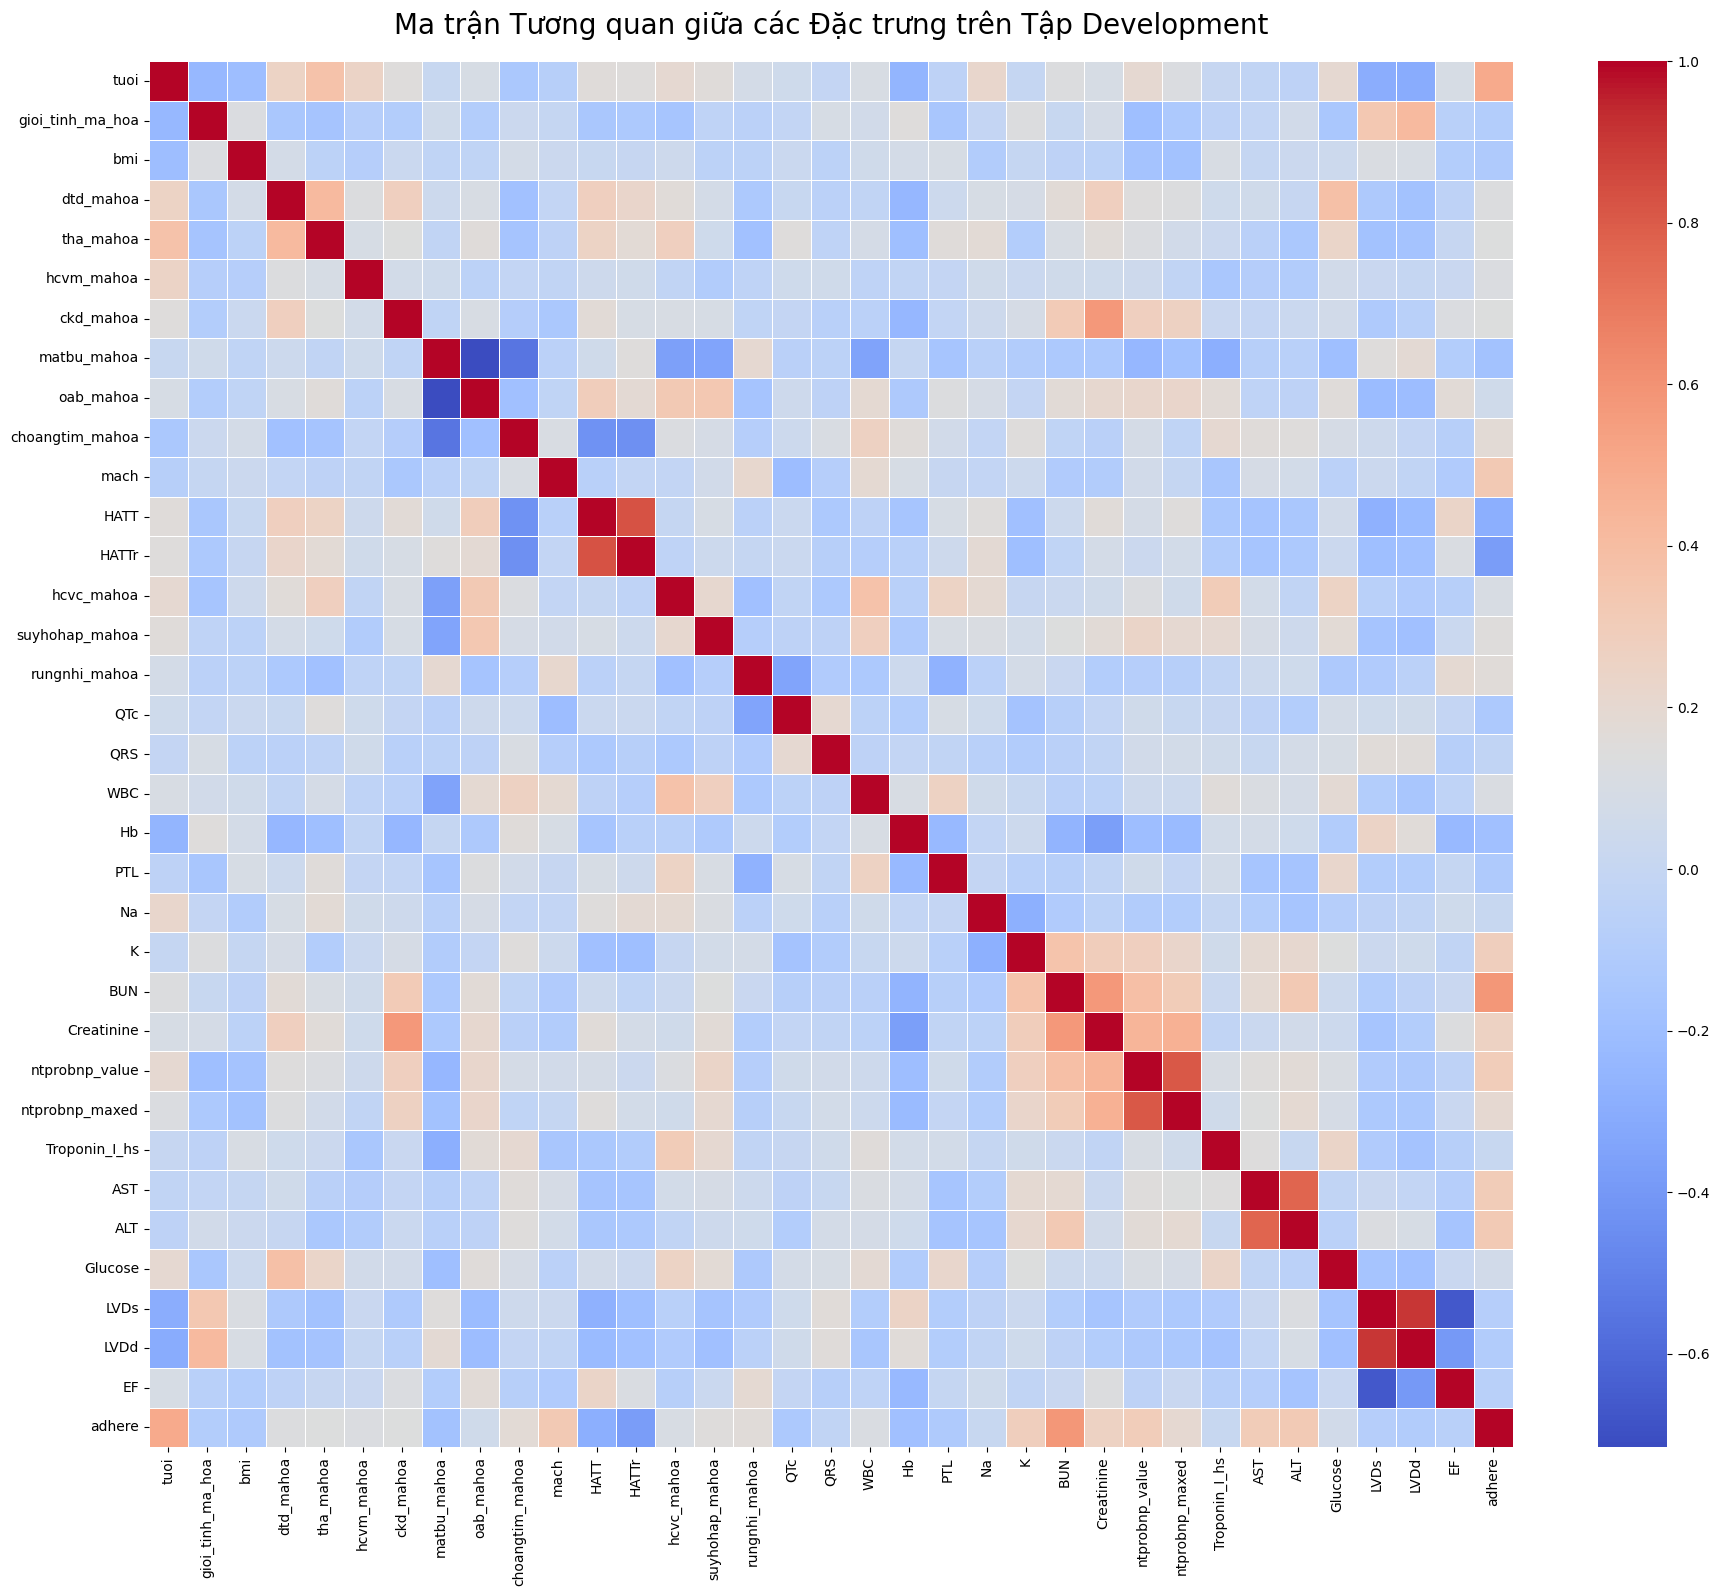


--------------------------------------------------------------------------------
TOP 15 CẶP ĐẶC TRƯNG CÓ TƯƠNG QUAN DƯƠNG CAO NHẤT:
LVDd            LVDs                0.911874
HATTr           HATT                0.830294
ntprobnp_maxed  ntprobnp_value      0.811864
ALT             AST                 0.765682
adhere          BUN                 0.578988
Creatinine      ckd_mahoa           0.577155
                BUN                 0.575011
adhere          tuoi                0.495323
ntprobnp_maxed  Creatinine          0.459177
ntprobnp_value  Creatinine          0.443391
LVDd            gioi_tinh_ma_hoa    0.411300
tha_mahoa       dtd_mahoa           0.410451
ntprobnp_value  BUN                 0.386246
Glucose         dtd_mahoa           0.381479
WBC             hcvc_mahoa          0.364367
--------------------------------------------------------------------------------

--------------------------------------------------------------------------------
TOP 15 CẶP ĐẶC TRƯNG CÓ TƯƠNG

In [74]:
# Sử dụng tập development đã được điền dữ liệu để tính toán
print("Tính toán ma trận tương quan trên tập X_dev_cleaned...")
corr_matrix = X_dev_cleaned.corr()

# Vẽ biểu đồ nhiệt (heatmap) để trực quan hóa ma trận
plt.figure(figsize=(22, 18))
sns.heatmap(corr_matrix,
            cmap='coolwarm', # Chọn colormap phân cực để dễ dàng thấy tương quan âm/dương
            annot=False,     # Không hiển thị số vì có quá nhiều đặc trưng, sẽ bị rối
            linewidths=.5)

plt.title('Ma trận Tương quan giữa các Đặc trưng trên Tập Development', fontsize=20, pad=20)
plt.show()

upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Chuyển ma trận thành một Series và loại bỏ các giá trị rỗng
high_corr_series = upper_tri.unstack().dropna()

# Sắp xếp để tìm các cặp có tương quan dương cao nhất
top_positive_corr = high_corr_series.sort_values(ascending=False)
print("\n" + "-"*80)
print("TOP 15 CẶP ĐẶC TRƯNG CÓ TƯƠNG QUAN DƯƠNG CAO NHẤT:")
print(top_positive_corr.head(15).to_string())
print("-" * 80)


# Sắp xếp để tìm các cặp có tương quan âm mạnh nhất
top_negative_corr = high_corr_series.sort_values(ascending=True)
print("\n" + "-"*80)
print("TOP 15 CẶP ĐẶC TRƯNG CÓ TƯƠNG QUAN ÂM MẠNH NHẤT:")
print(top_negative_corr.head(15).to_string())
print("-" * 80)

In [75]:
# ============================
# PHẦN X: p-value Logistic (Bootstrap 2000)
# ============================

import numpy as np
import pandas as pd
import statsmodels.api as sm

SEED_BOOT = 42
N_BOOT = 2000

# 1) Lấy pipeline Logistic đã huấn luyện trên dev
logreg_model_name = 'LogReg (ClassWeight)'
logreg_pipeline = final_results[logreg_model_name]['model']

preprocessor = logreg_pipeline.named_steps['preprocessor']
selector     = logreg_pipeline.named_steps['feature_selection']
classifier   = logreg_pipeline.named_steps['classifier']

# 2) Tên đặc trưng sau SelectKBest
selected_feature_names = selector.get_feature_names_out(input_features=X_dev_cleaned.columns)
cleaned_feature_names  = [n.replace('num__', '') for n in selected_feature_names]

# 3) Chuẩn bị ma trận thiết kế cho statsmodels
X_dev_processed = preprocessor.transform(X_dev_cleaned)
X_dev_selected  = selector.transform(X_dev_processed)
X_dev_sm        = sm.add_constant(X_dev_selected)   # thêm intercept

# 4) Fit mô hình Logit (MLE) trên toàn bộ dev để lấy hệ số quan sát
logit_full = sm.Logit(y_dev, X_dev_sm)
res_full   = logit_full.fit(disp=0)

beta_obs   = res_full.params[1:]               # bỏ intercept
coef_skl   = classifier.coef_[0]               # hệ số từ sklearn (để in)
or_hat     = np.exp(coef_skl)

# 5) Paired bootstrap: resample chỉ số, giữ cặp (X,y)
rng = np.random.RandomState(SEED_BOOT)
coefs_boot = np.empty((N_BOOT, X_dev_selected.shape[1]))
coefs_boot[:] = np.nan
n_fail = 0

def stratified_boot_idx(y, size, rng):
    y = np.asarray(y)
    pos = np.where(y == 1)[0]
    neg = np.where(y == 0)[0]
    n_pos = int(round(len(pos) / len(y) * size))
    n_neg = size - n_pos
    idx = np.concatenate([rng.choice(pos, n_pos, True),
                          rng.choice(neg, n_neg, True)])
    rng.shuffle(idx)
    return idx

for b in range(N_BOOT):
    idx = stratified_boot_idx(y_dev.values, len(y_dev), rng)
    y_b  = y_dev.values[idx]
    if np.unique(y_b).size < 2:
        n_fail += 1
        continue
    Xb = X_dev_sm[idx, :]
    try:
        res_b = sm.Logit(y_b, Xb).fit(disp=0, maxiter=200)
        coefs_boot[b, :] = res_b.params[1:]   # bỏ intercept
    except Exception:
        n_fail += 1
        continue

# 6) Tính p‑value hai phía từ phân bố bootstrap quanh 0 (theo dấu beta quan sát)
p_boot = []
for j in range(coefs_boot.shape[1]):
    bj = coefs_boot[:, j]
    bj = bj[~np.isnan(bj)]
    if bj.size == 0:
        p_boot.append(np.nan); continue
    if beta_obs[j] >= 0:
        p = 2 * np.mean(bj <= 0)
    else:
        p = 2 * np.mean(bj >= 0)
    p_boot.append(min(p, 1.0))
p_boot = np.array(p_boot)

# (tuỳ chọn) Khoảng tin cậy 95% cho OR từ bootstrap
beta_lo = np.nanpercentile(coefs_boot, 2.5, axis=0)
beta_hi = np.nanpercentile(coefs_boot, 97.5, axis=0)
or_lo   = np.exp(beta_lo)
or_hi   = np.exp(beta_hi)

# 7) Bảng kết quả
out = pd.DataFrame({
    "Feature": cleaned_feature_names,
    "Coefficient (sklearn)": coef_skl,
    "OR_hat": or_hat,
    "OR_CI_2.5%": or_lo,
    "OR_CI_97.5%": or_hi,
    "p_boot_two_sided": p_boot
}).sort_values("p_boot_two_sided")

print(f"Bootstrap hoàn tất: {N_BOOT} vòng; số vòng bỏ/không hội tụ: {n_fail}.")
print(out.to_string(index=False, float_format=lambda x: f"{x:.4f}"))


/Users/top/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/top/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/top/miniconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/top/miniconda3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/Users/top/miniconda3/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encounte

Bootstrap hoàn tất: 2000 vòng; số vòng bỏ/không hội tụ: 114.
         Feature  Coefficient (sklearn)  OR_hat  OR_CI_2.5%  OR_CI_97.5%  p_boot_two_sided
 choangtim_mahoa                 1.1109  3.0371      1.7248     536.0798            0.0011
  ntprobnp_value                 1.2284  3.4156      1.5979     267.6002            0.0074
       dtd_mahoa                -0.4396  0.6443      0.0000       1.5687            0.1888
          adhere                 0.4622  1.5876      0.6262      27.9745            0.1972
gioi_tinh_ma_hoa                -0.5769  0.5616      0.0404       1.5858            0.2259
             bmi                 0.3676  1.4443      0.5832      27.7771            0.2715
      hcvc_mahoa                 0.5065  1.6594      0.5188       9.3363            0.2757
             AST                -0.1487  0.8618      0.0074       1.8398            0.2831
           HATTr                 0.4036  1.4972      0.2697     400.0968            0.3118
  suyhohap_mahoa             